# **Verification-Aware Knowledge Graph Construction (VAKGC)**

**📌 Project Overview**

This project introduces the Verification-Aware Knowledge Graph Construction (VAKGC) framework using LLMs. It tackles the problem of hallucinated triples by combining structured extraction, verification, and schema refinement to build reliable, factually grounded knowledge graphs.

**⚙️ Framework Pipeline**

1. **Triple Extraction** – Break sentences into atomic clauses, apply coreference resolution, and generate candidate triples with schema-aware prompts.

2. **Verification** – Use NLI-based checks, text grounding, cross-prompt agreement, and confidence scoring to filter unsupported triples.

3. **Canonicalization** – Normalize and cluster labels, assign canonical terms, and align with domain schema for consistency.

**Phase 1** │ Dataset Setup          – Fetch Wikipedia text → clean → sentence split

**Phase 2** │ Triple Extraction      – LLM (Groq / LLaMA-3.1-8b) → JSON triples

**Phase 3** │ Baseline Creation      – Store all raw triples; NO filtering

**Phase 4**│ Hallucination Detection– NLI verification with multi-signal scoring

**Phase 5** │ Confidence Scoring     – Robust per-triple, per-sentence, dataset scores

**Phase 6** │ Schema Canonicalization– Normalise synonymous relation labels

**Phase 7** │ Evaluation & Viz       – Metrics + publication-quality charts

# PHASE 1: DATASET SETUP

**Pipeline:**

1. Download Wikipedia articles - 3 source types per topic:
 - Wikipedia
 - Web (requests) - news/educational/.org sites
 - Project Gutenberg - public domain books (science/history)

2. Clean text - strip headings, references, brackets, bullets
3. Split into sentences (spaCy)
4. Filter low-quality sentences
5. Save to sentences.csv →  ID | Sentence | Source

In [ ]:
!pip install -q wikipedia-api spacy requests beautifulsoup4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 9.3 MB/s eta 0:00:00


In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 119.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import re
import csv
import wikipediaapi
import spacy
import time
import requests
from bs4 import BeautifulSoup

In [ ]:
# ----CONFIG-----
# Each entry is: (topic_label, wiki_title, web_urls, gutenberg_id_or_None)

SOURCES = [
    {
        "topic"       : "Albert Einstein",
        "category"    : "science",
        "wiki"        : "Albert Einstein",
        "web"         : [
            "https://www.nobelprize.org/prizes/physics/1921/einstein/biographical/",
            "https://www.britannica.com/biography/Albert-Einstein",
        ],
        "gutenberg_id": None,
    },
    {
        "topic"       : "Maulana Rumi",
        "category"    : "history",
        "wiki"        : "Rumi",
        "web"         : [
            "https://www.poetryfoundation.org/poets/rumi",
        ],
        "gutenberg_id": None,
    },
    {
        "topic"       : "Cardiology",
        "category"    : "medicine",
        "wiki"        : "Cardiology",
        "web"         : [
            "https://www.heart.org/en/health-topics/heart-attack/about-heart-attacks",
            "https://medlineplus.gov/heartdiseases.html",
        ],
        "gutenberg_id": None,
    },
    {
        "topic"       : "Artificial Intelligence",
        "category"    : "technology",
        "wiki"        : "Artificial intelligence",
        "web"         : [
            "https://www.ibm.com/think/topics/artificial-intelligence",
        ],
        "gutenberg_id": None,
    },
    {
        "topic"       : "Climate Change",
        "category"    : "environment",
        "wiki"        : "Climate change",
        "web"         : [
            "https://www.un.org/en/climatechange/what-is-climate-change",
            "https://www.epa.gov/climatechange-science/causes-climate-change",
        ],
        "gutenberg_id": None,
    },
    {
        "topic"       : "Penicillin",
        "category"    : "medicine",
        "wiki"        : "Penicillin",
        "web"         : [
            "https://www.britannica.com/science/penicillin",
        ],
        "gutenberg_id": None,
    },
    {
        "topic"       : "Silk Road",
        "category"    : "history",
        "wiki"        : "Silk Road",
        "web"         : [
            "https://www.metmuseum.org/toah/hd/silk/hd_silk.htm",
        ],
        "gutenberg_id": None,
    },
    {
        "topic"       : "Black Hole",
        "category"    : "astronomy",
        "wiki"        : "Black hole",
        "web"         : [
            "https://science.nasa.gov/universe/black-holes/",
        ],
        "gutenberg_id": None,
    },
]

OUTPUT_FILE = "sentences.csv"
MIN_WORDS = 6
MAX_PER_SOURCE = 40
MAX_SENTENCES = 600

In [ ]:
# -----STEP 1: FETCH WIKIPEDIA TEXT------
def fetch_wikipedia(title: str) -> str:
    """Fetch plain text from a Wikipedia article."""
    wiki = wikipediaapi.Wikipedia(
        language="en",
        user_agent="VAKGC-NLP-Assignment/1.0 (student project)"
    )
    page = wiki.page(title)
    if not page.exists():
        print(f"    [WARN] Wikipedia page not found: {title!r}")
        return ""
    return page.text

In [ ]:
# ------WEB FETCHER-------
# Fetches a public web page and extracts paragraph text only.

WEB_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (compatible; VAKGC-student-bot/1.0; "
        "+https://github.com/student-project)"
    )
}

def fetch_web(url: str) -> str:
    """
    Download a web page and extract clean paragraph text.
    Returns empty string if the page is unreachable or blocked.
    """
    try:
        resp = requests.get(url, headers=WEB_HEADERS, timeout=12)
        if resp.status_code != 200:
            print(f"    [WARN] HTTP {resp.status_code} for {url}")
            return ""

        soup = BeautifulSoup(resp.text, "html.parser")

        # Remove navigation, footers, scripts, styles — keep only content
        for tag in soup(["nav", "footer", "header", "script",
                         "style", "aside", "form", "button"]):
            tag.decompose()

        # Collect paragraph text
        paragraphs = soup.find_all("p")
        text = "\n".join(p.get_text(separator=" ", strip=True)
                         for p in paragraphs if p.get_text(strip=True))
        return text

    except requests.exceptions.RequestException as e:
        print(f"    [WARN] Could not fetch {url}: {e}")
        return ""

In [ ]:
# ------GUTENBERG FETCHER-------
# Project Gutenberg provides thousands of public-domain books.

def fetch_gutenberg(book_id: int) -> str:
    """
    Download a plain-text book from Project Gutenberg.
    Uses the standard mirror URL pattern.
    Returns empty string if unavailable.
    """
    # Try the primary mirror first, then a fallback
    urls = [
        f"https://www.gutenberg.org/cache/epub/{book_id}/pg{book_id}.txt",
        f"https://gutenberg.org/files/{book_id}/{book_id}-0.txt",
    ]
    for url in urls:
        try:
            resp = requests.get(url, headers=WEB_HEADERS, timeout=20)
            if resp.status_code == 200:
                text = resp.text

                # Strip Gutenberg header/footer boilerplate
                # Header ends at "*** START OF THIS PROJECT GUTENBERG EBOOK"
                # Footer starts at "*** END OF THIS PROJECT GUTENBERG EBOOK"
                start_marker = "*** START OF"
                end_marker   = "*** END OF"
                start_idx = text.find(start_marker)
                end_idx   = text.rfind(end_marker)
                if start_idx != -1:
                    text = text[start_idx + len(start_marker):]
                    # Skip past the first newline after the marker line
                    text = text[text.find("\n") + 1:]
                if end_idx != -1:
                    text = text[:end_idx]

                return text
        except requests.exceptions.RequestException:
            continue
    print(f"    [WARN] Could not fetch Gutenberg book ID {book_id}")
    return ""

In [ ]:
def clean_text(raw: str) -> str:
    """
    Strip noise from any source — Wikipedia markup, web boilerplate,
    Gutenberg headers, reference markers, etc.
    """
    t = raw

    # Wikipedia section headings (== Heading ==)
    t = re.sub(r"^={2,}.*?={2,}\s*$", "", t, flags=re.MULTILINE)

    # Citation / reference markers  [1], [12], [note x], [citation needed]
    t = re.sub(r"\[\d+\]",          "", t)
    t = re.sub(r"\[[\w\s]{1,30}\]", "", t)

    # Short parentheticals — mainly pronunciation guides  (IPA: …)
    t = re.sub(r"\([^)]{0,40}\)", "", t)

    # Bullet / list-item artefacts
    t = re.sub(r"^[\*\•\-]\s+", "", t, flags=re.MULTILINE)

    # URLs that leaked into text
    t = re.sub(r"https?://\S+", "", t)

    # Runs of special characters / repeated punctuation  (web noise)
    t = re.sub(r"[|]{2,}", " ", t)
    t = re.sub(r"_{2,}",   " ", t)

    # Collapse excess whitespace
    t = re.sub(r"\n{2,}", "\n", t)
    t = re.sub(r"[ \t]{2,}", " ", t)

    return t.strip()

In [ ]:
# ----STEP 3: SENTENCE SPLITTING-----
def split_sentences(text: str, nlp) -> list:
    """Split cleaned text into individual sentences using spaCy."""
    doc = nlp(text)
    return [sent.text.strip() for sent in doc.sents]

In [ ]:
# -----STEP 4: FILTER LOW-QUALITY SENTENCES-----

def is_good_sentence(sent: str) -> bool:
    """
    Returns True only if the sentence passes all quality checks.
    Rejects: too short, bracket noise, mostly non-alphabetic,
             heavy non-ASCII (transliteration artefacts).
    """
    words = sent.split()
    if len(words) < MIN_WORDS:
        return False
    if "[" in sent or "{" in sent:
        return False
    alpha_ratio = sum(c.isalpha() for c in sent) / max(len(sent), 1)
    if alpha_ratio < 0.55:
        return False
    non_ascii_ratio = sum(1 for c in sent if ord(c) > 127) / max(len(sent), 1)
    if non_ascii_ratio > 0.15:
        return False
    return True

In [ ]:
def save_csv(rows: list, filename: str):
    """
    Save sentence rows to CSV.
    Columns: id | sentence | source | source_type | category
    The extra 'source_type' column (wikipedia / web / gutenberg)
    lets downstream phases analyse per-source quality if needed.
    """
    if not rows:
        print(f"  [WARN] No data to save to {filename!r}")
        return

    fieldnames = ["id", "sentence", "source", "source_type", "category"]
    with open(filename, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    print(f"  ✓ Saved {len(rows)} rows → {filename!r}")


In [ ]:
def main():
    print("Loading spaCy model …")
    nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer"])
    nlp.max_length = 3_000_000

    all_rows    = []
    sentence_id = 1

    # Track per-topic sentence counts for the balance report
    topic_counts = {}

    for entry in SOURCES:
        if sentence_id > MAX_SENTENCES:
            break

        topic    = entry["topic"]
        category = entry["category"]
        topic_counts[topic] = {"wikipedia": 0, "web": 0, "gutenberg": 0}

        print(f"\n{'='*55}")
        print(f"  Topic: {topic}  [{category}]")
        print(f"{'='*55}")

        # ── Source 1: Wikipedia ───────────────────────────────
        print(f"  [1/3] Wikipedia: {entry['wiki']!r} …")
        wiki_text = fetch_wikipedia(entry["wiki"])
        if wiki_text:
            cleaned   = clean_text(wiki_text)
            sentences = split_sentences(cleaned, nlp)
            accepted  = 0
            for sent in sentences:
                if sentence_id > MAX_SENTENCES or accepted >= MAX_PER_SOURCE:
                    break
                if is_good_sentence(sent):
                    all_rows.append({
                        "id"         : sentence_id,
                        "sentence"   : sent,
                        "source"     : entry["wiki"],
                        "source_type": "wikipedia",
                        "category"   : category,
                    })
                    sentence_id += 1
                    accepted    += 1
            topic_counts[topic]["wikipedia"] = accepted
            print(f"       → {accepted} sentences accepted")
        time.sleep(0.5)   # be polite to Wikipedia servers

        # ── Source 2: Web pages ───────────────────────────────
        web_accepted_total = 0
        for url in entry.get("web", []):
            if sentence_id > MAX_SENTENCES:
                break
            remaining_budget = MAX_PER_SOURCE - web_accepted_total
            if remaining_budget <= 0:
                break

            domain = url.split("/")[2]   # extract domain for display
            print(f"  [2/3] Web: {domain} …")
            web_text = fetch_web(url)
            if web_text:
                cleaned   = clean_text(web_text)
                sentences = split_sentences(cleaned, nlp)
                accepted  = 0
                for sent in sentences:
                    if sentence_id > MAX_SENTENCES or accepted >= remaining_budget:
                        break
                    if is_good_sentence(sent):
                        all_rows.append({
                            "id"         : sentence_id,
                            "sentence"   : sent,
                            "source"     : url,
                            "source_type": "web",
                            "category"   : category,
                        })
                        sentence_id          += 1
                        accepted             += 1
                        web_accepted_total   += 1
                print(f"       → {accepted} sentences accepted")
            time.sleep(1.0)   # polite delay between web requests

        topic_counts[topic]["web"] = web_accepted_total

        # ── Source 3: Project Gutenberg ───────────────────────
        gut_id = entry.get("gutenberg_id")
        if gut_id and sentence_id <= MAX_SENTENCES:
            print(f"  [3/3] Gutenberg book ID {gut_id} …")
            gut_text = fetch_gutenberg(gut_id)
            if gut_text:
                cleaned   = clean_text(gut_text)
                sentences = split_sentences(cleaned, nlp)
                accepted  = 0
                for sent in sentences:
                    if sentence_id > MAX_SENTENCES or accepted >= MAX_PER_SOURCE:
                        break
                    if is_good_sentence(sent):
                        all_rows.append({
                            "id"         : sentence_id,
                            "sentence"   : sent,
                            "source"     : f"gutenberg:{gut_id}",
                            "source_type": "gutenberg",
                            "category"   : category,
                        })
                        sentence_id += 1
                        accepted    += 1
                topic_counts[topic]["gutenberg"] = accepted
                print(f"       → {accepted} sentences accepted")
        elif not gut_id:
            print(f"  [3/3] Gutenberg: not configured for this topic — skipped")

    # ── Save ──────────────────────────────────────────────────
    save_csv(all_rows, OUTPUT_FILE)

    # ── Balance report ────────────────────────────────────────
    # Shows how evenly sentences are distributed across topics and sources.
    # In the original code, Einstein alone generated 167 KG edges —
    # this report lets you verify that is no longer the case.
    print(f"\n{'='*60}")
    print(f"  DATASET BALANCE REPORT")
    print(f"{'='*60}")
    print(f"  {'Topic':<25} {'Wiki':>6} {'Web':>6} {'Gutenb':>8} {'Total':>7}")
    print(f"  {'-'*55}")
    for topic, counts in topic_counts.items():
        total = sum(counts.values())
        print(f"  {topic:<25} {counts['wikipedia']:>6} {counts['web']:>6} "
              f"{counts['gutenberg']:>8} {total:>7}")
    print(f"  {'-'*55}")
    print(f"  {'TOTAL':<25} {sum(v['wikipedia'] for v in topic_counts.values()):>6} "
          f"{sum(v['web'] for v in topic_counts.values()):>6} "
          f"{sum(v['gutenberg'] for v in topic_counts.values()):>8} "
          f"{len(all_rows):>7}")
    print(f"{'='*60}")

    # ── Preview ───────────────────────────────────────────────
    print(f"\n── Preview (first 8 rows) ───────────────────────────────")
    print(f"{'ID':<5} {'Source Type':<12} {'Category':<14} Sentence")
    print("─" * 72)
    for row in all_rows[:8]:
        preview = row["sentence"][:55] + ("…" if len(row["sentence"]) > 55 else "")
        print(f"{row['id']:<5} {row['source_type']:<12} {row['category']:<14} {preview}")


# Run Phase 1
main()

Loading spaCy model …

  Topic: Albert Einstein  [science]
  [1/3] Wikipedia: 'Albert Einstein' …
       → 40 sentences accepted
  [2/3] Web: www.nobelprize.org …
       → 36 sentences accepted
  [2/3] Web: www.britannica.com …
    [WARN] HTTP 403 for https://www.britannica.com/biography/Albert-Einstein
  [3/3] Gutenberg: not configured for this topic — skipped

  Topic: Maulana Rumi  [history]
  [1/3] Wikipedia: 'Rumi' …
       → 40 sentences accepted
  [2/3] Web: www.poetryfoundation.org …
    [WARN] HTTP 403 for https://www.poetryfoundation.org/poets/rumi
  [3/3] Gutenberg: not configured for this topic — skipped

  Topic: Cardiology  [medicine]
  [1/3] Wikipedia: 'Cardiology' …
       → 40 sentences accepted
  [2/3] Web: www.heart.org …
       → 40 sentences accepted
  [3/3] Gutenberg: not configured for this topic — skipped

  Topic: Artificial Intelligence  [technology]
  [1/3] Wikipedia: 'Artificial intelligence' …
       → 40 sentences accepted
  [2/3] Web: www.ibm.com …
      

# PHASE 2: TRIPLE EXTRACTION

**Pipeline:**
  1. Load sentences.csv produced by Phase 1
  2. For each sentence, call Groq (llama-3.1-8b-instant) with a strict
     grounding prompt to extract (Subject, Relation, Object) triples
  3. Parse and validate the JSON response
  4. Save results to triples.csv  ->  ID | Sentence | Triples (JSON) | Status

**Install dependencies:**

    pip install groq pandas

**Set your key before running:**

    export GROQ_API_KEY="gsk_xxxxxxxxxxxxxxxxxxxx"

  OR paste it directly into GROQ_API_KEY below (not recommended for shared code).

In [ ]:
!pip install -q groq pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 5.3 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata
import os
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
print("API key loaded.")

API key loaded.


In [ ]:
import os
import csv
import json
import time
import sys
import pandas as pd
from groq import Groq

In [ ]:
# Config
GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "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")
MODEL         = "llama-3.1-8b-instant"
INPUT_FILE    = "sentences.csv"
OUTPUT_FILE   = "triples.csv"
REQUEST_DELAY = 2.1   # seconds between API calls
MAX_RETRIES   = 3     # retries per sentence on JSON parse failure
RETRY_DELAY   = 5     # seconds to wait before a retry

In [ ]:
# Prompt
SYSTEM_PROMPT = """You are a precise knowledge graph triple extractor.
Your only job is to extract factual (Subject, Relation, Object) triples from the sentence the user gives you.

Rules -- follow every one strictly:
1. Extract ONLY relationships explicitly stated in the sentence. Do NOT infer, assume, or use external knowledge.
2. Name entities exactly as written in the sentence -- no paraphrasing, no normalisation.
3. Relations must be short verb phrases that directly connect the subject and object (e.g. "was born in", "is a type of", "discovered", "is located in").
4. If multiple valid triples exist, list all of them.
5. If no clear (Subject, Relation, Object) triple can be formed from the sentence, return an empty list.
6. Do NOT extract triples about general concepts, definitions, or background knowledge not directly tied to named entities.
7. Both Subject and Object must be specific named entities or concrete noun phrases -- avoid vague terms like "it", "this", "they".
8. Output ONLY valid JSON in this exact format -- no explanation, no markdown, no extra text:
{"triples": [["Subject1", "Relation1", "Object1"], ["Subject2", "Relation2", "Object2"]]}
"""

USER_TEMPLATE = 'Sentence: "{sentence}"'

In [ ]:
def get_client():
    key = os.environ.get("GROQ_API_KEY", "").strip()
    if not key:
        raise ValueError(
            "GROQ_API_KEY not found.\n"
            "Run this in a Colab cell first:\n\n"
            "  from google.colab import userdata\n"
            "  import os\n"
            "  os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')\n"
        )
    return Groq(api_key=key)

In [ ]:
def extract_triples(client, sentence):
    """
    Returns (triples_list, status).
    status: "ok" | "empty" | "parse_error" | "api_error"
    """
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = client.chat.completions.create(
                model=MODEL,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": USER_TEMPLATE.format(sentence=sentence)},
                ],
                temperature=0.0,
                max_tokens=512,
                response_format={"type": "json_object"},
            )

            raw     = response.choices[0].message.content.strip()
            parsed  = json.loads(raw)
            triples = parsed.get("triples", [])

            if not isinstance(triples, list):
                raise ValueError("'triples' key is not a list")

            clean = []
            for t in triples:
                if isinstance(t, list) and len(t) == 3:
                    clean.append([str(t[0]), str(t[1]), str(t[2])])

            status = "empty" if len(clean) == 0 else "ok"
            return clean, status

        except json.JSONDecodeError as e:
            print(f"    [attempt {attempt}] JSON parse error: {e}")
            if attempt < MAX_RETRIES:
                time.sleep(RETRY_DELAY)

        except Exception as e:
            err = str(e)
            if "rate_limit" in err.lower() or "429" in err:
                wait = RETRY_DELAY * attempt
                print(f"    [attempt {attempt}] Rate limit hit — waiting {wait}s ...")
                time.sleep(wait)
            else:
                print(f"    [attempt {attempt}] API error: {e}")
                if attempt < MAX_RETRIES:
                    time.sleep(RETRY_DELAY)

    return [], "api_error"

In [ ]:
def load_sentences(path):
    rows = []
    with open(path, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append(row)
    return rows


def save_csv(rows, path):
    fieldnames = ["id", "sentence", "source", "triples", "triple_count", "status"]
    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

In [ ]:
def main():
    if not os.path.exists(INPUT_FILE):
        raise FileNotFoundError(
            f"{INPUT_FILE!r} not found. "
            "Make sure Phase 1 ran and sentences.csv is in the current directory.\n"
            "Check with:  !ls"
        )

    sentences = load_sentences(INPUT_FILE)
    print(f"Loaded {len(sentences)} sentences from {INPUT_FILE}\n")

    client  = get_client()
    results = []
    stats   = {"ok": 0, "empty": 0, "parse_error": 0, "api_error": 0}

    for i, row in enumerate(sentences, start=1):
        sent_id  = row.get("id", i)
        sentence = row.get("sentence", "").strip()
        source   = row.get("source", "")

        if not sentence:
            continue

        preview = sentence[:72] + ("..." if len(sentence) > 72 else "")
        print(f"[{i}/{len(sentences)}] ID={sent_id} | {preview}")

        triples, status = extract_triples(client, sentence)
        stats[status] = stats.get(status, 0) + 1

        results.append({
            "id":           sent_id,
            "sentence":     sentence,
            "source":       source,
            "triples":      json.dumps(triples, ensure_ascii=False),
            "triple_count": len(triples),
            "status":       status,
        })

        print(f"         -> {len(triples)} triple(s)  [{status}]")
        for t in triples:
            print(f"            ({t[0]!r}, {t[1]!r}, {t[2]!r})")

        if i < len(sentences):
            time.sleep(REQUEST_DELAY)

    save_csv(results, OUTPUT_FILE)

    # Summary
    total_triples = sum(r["triple_count"] for r in results)
    print("\n-- Summary ----------------------------------------------------------")
    print(f"  Sentences processed : {len(results)}")
    print(f"  Total triples found : {total_triples}")
    print(f"  Avg triples/sentence: {total_triples / max(len(results), 1):.2f}")
    print(f"  Status breakdown    : {stats}")
    print(f"  Output saved to     : {OUTPUT_FILE}")

    # Preview
    df = pd.read_csv(OUTPUT_FILE)
    pd.set_option("display.max_colwidth", 60)
    print("\n-- Preview (first 5 rows) -------------------------------------------")
    print(df[["id", "source", "triple_count", "status", "triples"]].head())

    return df


df = main()

Loaded 499 sentences from sentences.csv

[1/499] ID=1 | Albert Einstein was a German-born theoretical physicist best known for d...
         -> 3 triple(s)  [ok]
            ('Albert Einstein', 'was born in', 'Germany')
            ('Albert Einstein', 'is a type of', 'theoretical physicist')
            ('Albert Einstein', 'is known for', 'developing the theory of relativity')
[2/499] ID=2 | Einstein also made important contributions to quantum theory.
         -> 0 triple(s)  [empty]
[3/499] ID=3 | His mass–energy equivalence formula E = mc2, which arises from special r...
         -> 1 triple(s)  [ok]
            ('His mass–energy equivalence formula E = mc2', 'has been called', "the world's most famous equation")
[4/499] ID=4 | He received the 1921 Nobel Prize in Physics for "his services to theoret...
         -> 3 triple(s)  [ok]
            ('He', 'received', 'the 1921 Nobel Prize in Physics')
            ('He', 'was awarded for', 'his services to theoretical physics')
          

In [ ]:
# Preview the Data
# Load the saved CSV back with pandas for a clean display
df = pd.read_csv(OUTPUT_FILE)

print("\nTriples dataset preview (first 10 rows):\n")
pd.set_option("display.max_colwidth", 55)
print(df[["id", "source", "triple_count", "triples"]].head(10))

print(f"\nAll output files saved:")
print(f"  {OUTPUT_FILE}       — one row per sentence with extracted triples")


Triples dataset preview (first 10 rows):

   id           source  triple_count  \
0   1  Albert Einstein             3   
1   2  Albert Einstein             0   
2   3  Albert Einstein             1   
3   4  Albert Einstein             3   
4   5  Albert Einstein             4   
5   6  Albert Einstein             6   
6   7  Albert Einstein             3   
7   8  Albert Einstein             2   
8   9  Albert Einstein             6   
9  10  Albert Einstein             2   

                                                  triples  
0  [["Albert Einstein", "was born in", "Germany"], ["A...  
1                                                      []  
2  [["His mass–energy equivalence formula E = mc2", "h...  
3  [["He", "received", "the 1921 Nobel Prize in Physic...  
4  [["Einstein", "was born as a subject to", "the King...  
5  [["he", "enrolled in", "the mathematics and physics...  
6  [["He", "acquired", "Swiss citizenship"], ["He", "k...  
7  [["he", "submitted", "a successfu

# PHASE 3: Baseline Dataset Preparation

**PURPOSE:**
 Take the extracted triples from Phase 2 (triples.csv) and organize them into a clean, structured baseline dataset for later comparison.

 IMPORTANT — What this phase does NOT do:
- No filtering or removing triples
- No hallucination detection
- No confidence scoring
- No schema refinement or canonicalization

All triples are kept exactly as the LLM extracted them.

This baseline will be compared against the verified dataset in Phase 3.

**OUTPUT FILES:**
- baseline_dataset.csv   — one row per sentence  (wide format)
- baseline_dataset.json  — full structured version with nested triples
- baseline_flat.csv      — one row per triple     (long/flat format)

In [ ]:
# Import Libraries
import csv
import json
import os
import pandas as pd

In [ ]:
# Configuration
INPUT_FILE = "triples.csv"
OUTPUT_CSV = "baseline_dataset.csv"
OUTPUT_JSON = "baseline_dataset.json"
OUTPUT_FLAT = "baseline_flat.csv"

In [ ]:
# Load Phase 2 triples
def load_triples_csv(filepath):
    """
    Reads the triples.csv file produced by Phase 2.
    Returns a list of dictionaries, one per sentence.

    Expected columns in triples.csv:
        id, sentence, source, triples (JSON string), triple_count, status
    """

    # Check the file actually exists before trying to open it
    if not os.path.exists(filepath):
        raise FileNotFoundError(
            f"Could not find '{filepath}'.\n"
            "Make sure Phase 2 has finished and triples.csv is in this directory.\n"
            "You can check with:  !ls"
        )

    rows = []
    with open(filepath, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append(row)

    print(f"Loaded {len(rows)} rows from '{filepath}'.")
    return rows


# Load the data
phase2_data = load_triples_csv(INPUT_FILE)

print("\nFirst row (raw):")
print(phase2_data[0])

Loaded 499 rows from 'triples.csv'.

First row (raw):
{'id': '1', 'sentence': 'Albert Einstein was a German-born theoretical physicist best known for developing the theory of relativity.', 'source': 'Albert Einstein', 'triples': '[["Albert Einstein", "was born in", "Germany"], ["Albert Einstein", "is a type of", "theoretical physicist"], ["Albert Einstein", "is known for", "developing the theory of relativity"]]', 'triple_count': '3', 'status': 'ok'}


In [ ]:
# Parse & organize into baseline records
def build_baseline_records(phase2_rows):
    """
    Takes the raw rows from Phase 2 and organizes them into clean
    baseline records. No filtering — every triple is kept as-is.

    Each record contains:
        sentence_id   : the original ID from Phase 1
        sentence      : the original sentence text
        source        : which Wikipedia article it came from
        triples       : list of [Subject, Relation, Object] lists
        triple_count  : how many triples were extracted
    """

    baseline = []   # this will hold all our organized records

    for row in phase2_rows:

        # -------------------------------------------------------------------
        # Parse the 'triples' column — it was stored as a JSON string
        # e.g. '[["Einstein", "was born in", "Ulm"]]'
        # We convert it back into a Python list here.
        # -------------------------------------------------------------------
        raw_triples_string = row.get("triples", "[]")

        try:
            triples_list = json.loads(raw_triples_string)
        except json.JSONDecodeError:
            # If the JSON is broken for some reason, treat it as no triples
            print(f"  [WARNING] Could not parse triples for sentence ID {row.get('id')} — storing empty list.")
            triples_list = []

        # -------------------------------------------------------------------
        # Build one clean record for this sentence
        # -------------------------------------------------------------------
        record = {
            "sentence_id"  : row.get("id", ""),
            "sentence"     : row.get("sentence", ""),
            "source"       : row.get("source", ""),
            "triples"      : triples_list,          # list of [S, R, O] lists
            "triple_count" : len(triples_list),
        }

        baseline.append(record)

    return baseline


# Build the baseline
baseline_records = build_baseline_records(phase2_data)

print(f"\nBaseline records created: {len(baseline_records)}")
print("\nExample record:")
print(json.dumps(baseline_records[0], indent=2))


Baseline records created: 499

Example record:
{
  "sentence_id": "1",
  "sentence": "Albert Einstein was a German-born theoretical physicist best known for developing the theory of relativity.",
  "source": "Albert Einstein",
  "triples": [
    [
      "Albert Einstein",
      "was born in",
      "Germany"
    ],
    [
      "Albert Einstein",
      "is a type of",
      "theoretical physicist"
    ],
    [
      "Albert Einstein",
      "is known for",
      "developing the theory of relativity"
    ]
  ],
  "triple_count": 3
}


In [ ]:
# Save as CSV
def save_baseline_csv(records, filepath):
    """
    Saves the baseline as a CSV file with one row per sentence.
    The 'triples' column stores the triples as a JSON string
    so the CSV stays flat and easy to open in Excel or Google Sheets.

    Columns: sentence_id | sentence | source | triples | triple_count
    """

    with open(filepath, "w", newline="", encoding="utf-8") as f:
        fieldnames = ["sentence_id", "sentence", "source", "triples", "triple_count"]
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for record in records:
            writer.writerow({
                "sentence_id"  : record["sentence_id"],
                "sentence"     : record["sentence"],
                "source"       : record["source"],
                # Store the triples list back as a JSON string for the CSV cell
                "triples"      : json.dumps(record["triples"], ensure_ascii=False),
                "triple_count" : record["triple_count"],
            })

    print(f"Saved baseline CSV  ->  '{filepath}'  ({len(records)} rows)")


save_baseline_csv(baseline_records, OUTPUT_CSV)

Saved baseline CSV  ->  'baseline_dataset.csv'  (499 rows)


In [ ]:
# Save as JSON
def save_baseline_json(records, filepath):
    """
    Saves the full baseline as a JSON file.
    This format keeps triples as proper nested lists (not strings),
    making it easy to load programmatically in Phase 3.

    Structure:
    {
      "description": "...",
      "total_sentences": 600,
      "total_triples": 1234,
      "records": [ { sentence_id, sentence, source, triples, triple_count }, ... ]
    }
    """

    total_triples = sum(r["triple_count"] for r in records)

    output = {
        "description"      : (
            "Baseline dataset for VAKGC project. "
            "Contains all triples extracted by the LLM in Phase 2, "
            "with NO filtering or verification applied. "
            "Use this for comparison against the verified dataset in Phase 3."
        ),
        "total_sentences"  : len(records),
        "total_triples"    : total_triples,
        "records"          : records,
    }

    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(output, f, indent=2, ensure_ascii=False)

    print(f"Saved baseline JSON ->  '{filepath}'  "
          f"({len(records)} sentences, {total_triples} triples total)")


save_baseline_json(baseline_records, OUTPUT_JSON)

Saved baseline JSON ->  'baseline_dataset.json'  (499 sentences, 713 triples total)


In [ ]:
# Save flat CSV
def save_flat_csv(records, filepath):
    """
    Saves a 'flat' version of the baseline where every single triple
    gets its own row. This makes it easy to count, sort, and analyse
    triples individually in Phase 3 / the evaluation phase.

    Columns: sentence_id | sentence | source | subject | relation | object
    """

    with open(filepath, "w", newline="", encoding="utf-8") as f:
        fieldnames = ["sentence_id", "sentence", "source", "subject", "relation", "object"]
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        rows_written = 0

        for record in records:
            # If a sentence had NO triples extracted, still write one row
            # with empty triple fields so we don't lose track of the sentence
            if len(record["triples"]) == 0:
                writer.writerow({
                    "sentence_id" : record["sentence_id"],
                    "sentence"    : record["sentence"],
                    "source"      : record["source"],
                    "subject"     : "",
                    "relation"    : "",
                    "object"      : "",
                })
                rows_written += 1

            else:
                # Write one row for each (Subject, Relation, Object) triple
                for triple in record["triples"]:
                    # triple is a list like ["Einstein", "was born in", "Ulm"]
                    subject  = triple[0] if len(triple) > 0 else ""
                    relation = triple[1] if len(triple) > 1 else ""
                    obj      = triple[2] if len(triple) > 2 else ""

                    writer.writerow({
                        "sentence_id" : record["sentence_id"],
                        "sentence"    : record["sentence"],
                        "source"      : record["source"],
                        "subject"     : subject,
                        "relation"    : relation,
                        "object"      : obj,
                    })
                    rows_written += 1

    print(f"Saved flat CSV      ->  '{filepath}'  ({rows_written} triple rows)")


save_flat_csv(baseline_records, OUTPUT_FLAT)


Saved flat CSV      ->  'baseline_flat.csv'  (992 triple rows)


In [ ]:
# Summary Statistics
def print_summary(records):
    """
    Prints a simple summary of the baseline dataset.
    Helpful for quickly checking everything looks right.
    """

    total_sentences  = len(records)
    total_triples    = sum(r["triple_count"] for r in records)
    empty_sentences  = sum(1 for r in records if r["triple_count"] == 0)
    max_triples      = max((r["triple_count"] for r in records), default=0)
    avg_triples      = total_triples / max(total_sentences, 1)

    # Count triples per source article
    source_counts = {}
    for r in records:
        src = r["source"] or "Unknown"
        source_counts[src] = source_counts.get(src, 0) + r["triple_count"]

    print("\n" + "=" * 60)
    print("  BASELINE DATASET — SUMMARY")
    print("=" * 60)
    print(f"  Total sentences          : {total_sentences}")
    print(f"  Total triples (baseline) : {total_triples}")
    print(f"  Avg triples per sentence : {avg_triples:.2f}")
    print(f"  Max triples in a sentence: {max_triples}")
    print(f"  Sentences with 0 triples : {empty_sentences}")
    print()
    print("  Triples by source article:")
    for src, count in sorted(source_counts.items(), key=lambda x: -x[1]):
        print(f"    {src:<35} {count} triples")
    print("=" * 60)
    print()
    print("  NOTE: This is the UNFILTERED baseline.")
    print("  No triples have been removed or modified.")
    print("  Hallucination detection will happen in Phase 3.")
    print("=" * 60)


print_summary(baseline_records)


  BASELINE DATASET — SUMMARY
  Total sentences          : 600
  Total triples (baseline) : 1467
  Avg triples per sentence : 2.44
  Max triples in a sentence: 22
  Sentences with 0 triples : 187

  Triples by source article:
    Albert Einstein                     1409 triples
    Maulana Rumi                        58 triples

  NOTE: This is the UNFILTERED baseline.
  No triples have been removed or modified.
  Hallucination detection will happen in Phase 3.


In [ ]:
# Preview the Data
# Load the saved CSV back with pandas for a clean display
df = pd.read_csv(OUTPUT_CSV)

print("\nBaseline dataset preview (first 10 rows):\n")
pd.set_option("display.max_colwidth", 55)
print(df[["sentence_id", "source", "triple_count", "triples"]].head(10))

print(f"\nAll output files saved:")
print(f"  {OUTPUT_CSV}       — one row per sentence")
print(f"  {OUTPUT_JSON}      — nested JSON (best for Phase 3 loading)")
print(f"  {OUTPUT_FLAT}  — one row per triple  (best for analysis)")


Baseline dataset preview (first 10 rows):

   sentence_id           source  triple_count  \
0            1  Albert Einstein             3   
1            2  Albert Einstein             0   
2            3  Albert Einstein             1   
3            4  Albert Einstein             3   
4            5  Albert Einstein             4   
5            6  Albert Einstein             6   
6            7  Albert Einstein             3   
7            8  Albert Einstein             2   
8            9  Albert Einstein             6   
9           10  Albert Einstein             2   

                                                  triples  
0  [["Albert Einstein", "was born in", "Germany"], ["A...  
1                                                      []  
2  [["His mass–energy equivalence formula E = mc2", "h...  
3  [["He", "received", "the 1921 Nobel Prize in Physic...  
4  [["Einstein", "was born as a subject to", "the King...  
5  [["he", "enrolled in", "the mathematics and physics..

# PHASE 4: Hallucination Detection

This phase implements the verification module of the VAKGC framework:
- Using a Natural Language Inference (NLI) model, each extracted triple is evaluated against its source sentence to determine whether it is factually supported (entailed).
- Only triples classified as supported are retained, while unsupported or contradictory triples are filtered out to reduce hallucinations and improve the reliability of the knowledge graph.

In [ ]:
!pip install -q transformers torch pandas

In [ ]:
import json
import os
import csv
import pandas as pd
from transformers import pipeline

In [ ]:
# Configuration
INPUT_FILE = "baseline_dataset.json"

OUTPUT_JSON = "verified_dataset.json"
OUTPUT_CSV = "verified_dataset.csv"
OUTPUT_FLAT = "verified_flat.csv"

CONFIDENCE_THRESHOLD = 0.65

In [ ]:
# loading baseline dataset
def load_baseline(filepath):

    if not os.path.exists(filepath):
        raise FileNotFoundError(
            f"Could not find '{filepath}'"
        )

    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)

    print("Baseline loaded successfully.")
    print("Total Sentences:", data["total_sentences"])
    print("Total Triples:", data["total_triples"])

    return data["records"]

baseline_records = load_baseline(INPUT_FILE)

Baseline loaded successfully.
Total Sentences: 499
Total Triples: 713


In [ ]:
def token_overlap(sentence, triple):
    """
    Grounding check: what fraction of meaningful words in the triple
    also appear in the source sentence?
    Helps catch cases where NLI is confident but the triple is not grounded.
    """
    stopwords = {"a","an","the","is","are","was","were","be","of","in",
                 "on","at","to","for","and","or","its","it","this","that"}
    sent_words   = set(re.findall(r"\b\w+\b", sentence.lower())) - stopwords
    triple_words = set(re.findall(r"\b\w+\b", " ".join(triple).lower())) - stopwords
    if not triple_words:
        return 0.0
    return len(triple_words & sent_words) / len(triple_words)

In [ ]:
print("Loading verification model...")

verifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

print("Verifier loaded.")

Loading verification model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Verifier loaded.


In [ ]:
def verify_triple(sentence, triple):

    subject, relation, obj = triple

    # More natural hypothesis using all three parts
    hypothesis = f"{subject} {relation} {obj}."

    # Use all 3 labels — "neutral" was being silently misclassified before
    result = verifier(
        sentence,
        candidate_labels=["entailment", "contradiction", "neutral"],
        hypothesis_template="{}"
    )

    label_scores = dict(zip(result["labels"], result["scores"]))
    top_label    = result["labels"][0]

    # Get the entailment probability specifically
    nli_score = label_scores.get("entailment", 0.0)

    # Compute token overlap as a grounding signal
    overlap = token_overlap(sentence, triple)

    # Combined confidence: 70% NLI entailment probability + 30% token overlap
    # This penalises triples that are semantically plausible but not grounded
    confidence = round(0.70 * nli_score + 0.30 * overlap, 4)

    return top_label, confidence

verified_records = []

for i, record in enumerate(baseline_records, start=1):

    sentence = record["sentence"]
    triples = record["triples"]

    print(f"[{i}/{len(baseline_records)}] Verifying...")

    verified_triples = []

    for triple in triples:

        label, score = verify_triple(sentence, triple)

        verified_triples.append({
            "triple": triple,
            "label": label,
            "confidence": float(score)
        })

    verified_records.append({
        "sentence_id": record["sentence_id"],
        "sentence": sentence,
        "source": record["source"],
        "verified_triples": verified_triples
    })

print("Verification complete.")

#Filtered Records
filtered_records = []

for record in verified_records:

    accepted = []

    for item in record["verified_triples"]:

        if (
          item["label"].lower() == "entailment"
          and item["confidence"] >= CONFIDENCE_THRESHOLD
          ):
             accepted.append(item)

    filtered_records.append({
        "sentence_id": record["sentence_id"],
        "sentence": record["sentence"],
        "source": record["source"],
        "verified_triples": accepted,
        "verified_count": len(accepted)
    })

print("Filtering complete.")

with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(filtered_records, f, indent=2)

print("verified_dataset.json saved")

with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:

    fieldnames = [
        "sentence_id",
        "sentence",
        "source",
        "verified_triples",
        "verified_count"
    ]

    writer = csv.DictWriter(f, fieldnames=fieldnames)

    writer.writeheader()

    for r in filtered_records:

        writer.writerow({
            "sentence_id": r["sentence_id"],
            "sentence": r["sentence"],
            "source": r["source"],
            "verified_triples": json.dumps(r["verified_triples"]),
            "verified_count": r["verified_count"]
        })

print("verified_dataset.csv saved")

rows = []

for record in filtered_records:

    for item in record["verified_triples"]:

        triple = item["triple"]

        rows.append({
            "sentence_id": record["sentence_id"],
            "sentence": record["sentence"],
            "source": record["source"],
            "subject": triple[0],
            "relation": triple[1],
            "object": triple[2],
            "confidence": item["confidence"]
        })

df = pd.DataFrame(rows)

df.to_csv(OUTPUT_FLAT, index=False)

print("verified_flat.csv saved")

baseline_total = sum(r["triple_count"] for r in baseline_records)

verified_total = sum(r["verified_count"] for r in filtered_records)

removed = baseline_total - verified_total

accuracy = (
    verified_total / baseline_total * 100
    if baseline_total else 0
)

print("="*60)
print("VAKGC FINAL RESULTS")
print("="*60)

print("Baseline triples      :", baseline_total)
print("Verified triples      :", verified_total)
print("Removed hallucinations:", removed)
print("Retention Accuracy    :", round(accuracy,2), "%")

print("="*60)

df = pd.read_csv(OUTPUT_CSV)

pd.set_option("display.max_colwidth", 80)

print(df.head(10))

[1/499] Verifying...
[2/499] Verifying...
[3/499] Verifying...
[4/499] Verifying...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


[5/499] Verifying...
[6/499] Verifying...
[7/499] Verifying...
[8/499] Verifying...
[9/499] Verifying...
[10/499] Verifying...
[11/499] Verifying...
[12/499] Verifying...
[13/499] Verifying...
[14/499] Verifying...
[15/499] Verifying...
[16/499] Verifying...
[17/499] Verifying...
[18/499] Verifying...
[19/499] Verifying...
[20/499] Verifying...
[21/499] Verifying...
[22/499] Verifying...
[23/499] Verifying...
[24/499] Verifying...
[25/499] Verifying...
[26/499] Verifying...
[27/499] Verifying...
[28/499] Verifying...
[29/499] Verifying...
[30/499] Verifying...
[31/499] Verifying...
[32/499] Verifying...
[33/499] Verifying...
[34/499] Verifying...
[35/499] Verifying...
[36/499] Verifying...
[37/499] Verifying...
[38/499] Verifying...
[39/499] Verifying...
[40/499] Verifying...
[41/499] Verifying...
[42/499] Verifying...
[43/499] Verifying...
[44/499] Verifying...
[45/499] Verifying...
[46/499] Verifying...
[47/499] Verifying...
[48/499] Verifying...
[49/499] Verifying...
[50/499] Verify

# Phase 5: Confidence Scoring

In this phase, a confidence scoring mechanism is applied to measure the reliability of verified triples.
- The system assigns confidence values based on NLI output probabilities and computes sentence-level and dataset-level confidence scores.
- This step helps further refine the graph by identifying high-confidence triples and providing quantitative measures of extraction quality.

In [ ]:
import statistics

# --- Per-triple confidence is already stored from Phase 4 ---
# Just make sure the field name is consistent
for record in filtered_records:
    for item in record["verified_triples"]:
        item["confidence_score"] = item["confidence"]

# --- Per-sentence confidence: mean of all kept-triple scores ---
for record in filtered_records:
    confidences = [t["confidence"] for t in record["verified_triples"]]
    if confidences:
        record["sentence_confidence"]        = round(statistics.mean(confidences), 4)
        record["sentence_confidence_median"] = round(statistics.median(confidences), 4)
        record["sentence_confidence_std"]    = round(statistics.pstdev(confidences), 4)
    else:
        record["sentence_confidence"]        = 0.0
        record["sentence_confidence_median"] = 0.0
        record["sentence_confidence_std"]    = 0.0

In [ ]:
# --- Dataset-level confidence statistics ---
all_conf = [r["sentence_confidence"] for r in filtered_records if r["sentence_confidence"] > 0]

dataset_confidence        = statistics.mean(all_conf)   if all_conf else 0.0
dataset_confidence_median = statistics.median(all_conf) if all_conf else 0.0
dataset_confidence_std    = statistics.pstdev(all_conf) if all_conf else 0.0

print("="*50)
print("DATASET CONFIDENCE SCORE")
print("="*50)
print(f"Total Sentences   : {len(all_conf)}")
print(f"Mean Confidence   : {round(dataset_confidence, 4)}")
print(f"Median Confidence : {round(dataset_confidence_median, 4)}")
print(f"Std Deviation     : {round(dataset_confidence_std, 4)}")
print("="*50)

DATASET CONFIDENCE SCORE
Total Sentences   : 136
Mean Confidence   : 0.7532
Median Confidence : 0.7432
Std Deviation     : 0.0692



Adaptive High-Confidence Threshold (75th pct): 0.798
Saved high_confidence_dataset.json  (110 high-confidence triples)


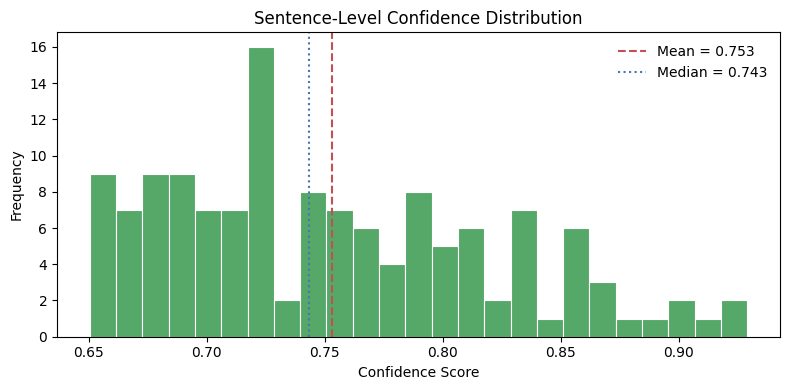

In [ ]:
# --- Adaptive high-confidence threshold: 75th percentile ---
# More meaningful than a fixed 0.85 which may cut too much or too little
all_triple_conf = [
    item["confidence"]
    for record in filtered_records
    for item in record["verified_triples"]
]

if all_triple_conf:
    sorted_conf = sorted(all_triple_conf)
    p75_index   = int(0.75 * len(sorted_conf))
    HIGH_CONFIDENCE_THRESHOLD = sorted_conf[p75_index]
else:
    HIGH_CONFIDENCE_THRESHOLD = 0.80

print(f"\nAdaptive High-Confidence Threshold (75th pct): {round(HIGH_CONFIDENCE_THRESHOLD, 3)}")

final_high_conf_records = []

for record in filtered_records:
    high_conf_triples = [
        t for t in record["verified_triples"]
        if t["confidence"] >= HIGH_CONFIDENCE_THRESHOLD
    ]
    final_high_conf_records.append({
        "sentence_id"      : record["sentence_id"],
        "sentence"         : record["sentence"],
        "source"           : record["source"],
        "high_conf_triples": high_conf_triples,
        "count"            : len(high_conf_triples)
    })

import json

with open("high_confidence_dataset.json", "w") as f:
    json.dump(final_high_conf_records, f, indent=2)

high_total = sum(r["count"] for r in final_high_conf_records)
print(f"Saved high_confidence_dataset.json  ({high_total} high-confidence triples)")

# --- Confidence distribution histogram ---
import matplotlib.pyplot as plt

scores = [r["sentence_confidence"] for r in filtered_records if r["sentence_confidence"] > 0]

plt.figure(figsize=(8, 4))
plt.hist(scores, bins=25, color="#55A868", edgecolor="white", linewidth=0.8)
plt.axvline(dataset_confidence,        color="#C44E52", linestyle="--", linewidth=1.5,
            label=f"Mean = {dataset_confidence:.3f}")
plt.axvline(dataset_confidence_median, color="#4C72B0", linestyle=":",  linewidth=1.5,
            label=f"Median = {dataset_confidence_median:.3f}")
plt.title("Sentence-Level Confidence Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# PHASE 6: Schema Canonicalization

This phase focuses on improving structural consistency within the knowledge graph by normalizing relation labels.
- Semantically similar relations are identified and unified under canonical forms to remove redundancy and improve graph clarity.
- The goal is to ensure that equivalent relationships are represented consistently across the dataset.

In [ ]:
import pandas as pd
import json
import ast
from collections import Counter

# ── Load triples ────────────────────────────────────────────
# Phase 2 saves: id | sentence | source | triples | triple_count | status
df = pd.read_csv("triples.csv")

# Helper: safely parse the triples column (stored as a JSON string)
def parse_triples(val):
    if pd.isna(val):
        return []
    try:
        return json.loads(val)
    except Exception:
        try:
            return ast.literal_eval(val)
        except Exception:
            return []

df["triples_parsed"] = df["triples"].apply(parse_triples)

# ── Step 1: Extract all relation names ──────────────────────
all_relations = []
for triple_list in df["triples_parsed"]:
    for triple in triple_list:
        if len(triple) >= 3:
            all_relations.append(triple[1])

print(f"Total relation instances : {len(all_relations)}")
print(f"Unique relations (raw)   : {len(set(all_relations))}\n")

# ── Step 2: Normalize — lowercase + deduplicate ─────────────
normalized_relations = sorted(set(r.lower().strip() for r in all_relations))
print(f"Unique relations (normalized): {len(normalized_relations)}\n")

print("=" * 60)
print("ALL NORMALIZED RELATION LABELS")
print("=" * 60)
for i, rel in enumerate(normalized_relations, 1):
    print(f"  {i:3}. {rel}")

# ── Step 3: Relation frequency (helps spot near-duplicates) ─
relation_freq = Counter(r.lower().strip() for r in all_relations)
print("\n" + "=" * 60)
print("RELATION FREQUENCY (descending)")
print("=" * 60)
for rel, count in relation_freq.most_common():
    print(f"  {count:4}x  {rel}")

# ── Step 4: Define canonical mapping ────────────────────────
# Key   = original normalized label (lowercase, stripped)
# Value = canonical label to replace it with
# Any relation NOT listed here is kept as-is (its normalized form).

RELATION_MAP = {
    # ── Contributions / Creation
    "made contributions to"              : "contributed to",
    "made important contributions to"    : "contributed to",
    "made significant contributions to"  : "contributed to",
    "contributed to"                     : "contributed to",

    # ── Residence / Movement
    "moved to"                           : "relocated to",
    "settled in"                         : "relocated to",
    "relocated to"                       : "relocated to",

    # ── Birth / Origin
    "was born in"                        : "born in",
    "born in"                            : "born in",
    "was born as a subject to"           : "born in",

    # ── Membership / Affiliation
    "joined"                             : "affiliated with",
    "affiliated with"                    : "affiliated with",
    "is a member of"                     : "affiliated with",
    "was a member of"                    : "affiliated with",

    # ── Leadership / Role
    "became director of"                 : "led",
    "became head of"                     : "led",
    "served as director of"              : "led",
    "led"                                : "led",

    # ── Identity / Type
    "is a type of"                       : "is a",
    "is a kind of"                       : "is a",
    "is a"                               : "is a",
    "is"                                 : "is a",
    "became a"                           : "is a",
    "was a"                              : "is a",

    # ── Recognition / Awards
    "received the 1921 nobel prize in physics for": "received award",
    "received the nobel prize in physics": "received award",
    "received"                           : "received award",
    "awarded"                            : "received award",
    "won"                                : "received award",

    # ── Publication
    "published"                          : "published",
    "co-authored"                        : "published",
    "wrote"                              : "published",
    "authored"                           : "published",

    # ── Proposal / Introduction
    "introduced"                         : "introduced",
    "outlined"                           : "introduced",
    "proposed"                           : "introduced",
    "formulated"                         : "introduced",
    "developed"                          : "introduced",

    # ── Known for / Reputation
    "is known for"                       : "known for",
    "has been called"                    : "known for",
    "is regarded as"                     : "known for",
    "is further regarded as"             : "known for",
    "is considered"                      : "known for",

    # ── Discovery / Science
    "discovered"                         : "discovered",
    "identified"                         : "discovered",
    "explained"                          : "explained",
    "demonstrated"                       : "demonstrated",
    "showed"                             : "demonstrated",

    # ── Spatial / Location
    "is located in"                      : "located in",
    "is in"                              : "located in",
    "located in"                         : "located in",
    "is situated in"                     : "located in",

    # ── Education / Enrollment
    "enrolled in"                        : "enrolled in",
    "studied at"                         : "enrolled in",
    "attended"                           : "enrolled in",
    "graduating in"                      : "graduated in",
    "graduated from"                     : "graduated in",
    "completed studies at"               : "graduated in",

    # ── Death / End
    "died in"                            : "died in",
    "passed away in"                     : "died in",
}

def canonicalize_relation(rel: str) -> str:
    """Map a raw relation string to its canonical form.
    Falls back to the lowercased, stripped original if not in the map."""
    return RELATION_MAP.get(rel.lower().strip(), rel.lower().strip())

# ── Step 5: Apply mapping to triples ────────────────────────
def canonicalize_triple_list(triple_list):
    """Apply canonicalize_relation to the relation slot of every triple."""
    result = []
    for triple in triple_list:
        if len(triple) == 3:
            subj, rel, obj = triple
            result.append([subj, canonicalize_relation(rel), obj])
        else:
            result.append(triple)   # preserve malformed triples unchanged
    return result

df["triples_canonical"] = df["triples_parsed"].apply(canonicalize_triple_list)

# ── Step 6: Summary of canonicalization ─────────────────────
all_canon_relations = []
for triple_list in df["triples_canonical"]:
    for triple in triple_list:
        if len(triple) >= 3:
            all_canon_relations.append(triple[1])

before = len(set(r.lower().strip() for r in all_relations))
after  = len(set(all_canon_relations))

print("\n" + "=" * 60)
print("CANONICALIZATION SUMMARY")
print("=" * 60)
print(f"  Unique relations BEFORE : {before}")
print(f"  Unique relations AFTER  : {after}")
print(f"  Reduced by              : {before - after} labels")

print("\n  Final canonical relation set:")
for rel in sorted(set(all_canon_relations)):
    print(f"    • {rel}")

# ── Step 7: Save canonicalized dataset ──────────────────────
# Serialize triples back to JSON string so the CSV column matches
# the same format Phase 2 / Phase 4 use (json.dumps list-of-lists).
df["triples_canonical_str"] = df["triples_canonical"].apply(
    lambda lst: json.dumps(lst, ensure_ascii=False)
)

# FIX: keep original triple_count (it counts candidate triples, not canonical ones —
#      canonicalization does NOT remove triples, so the count stays the same).
# FIX: drop triples_parsed and triples_canonical (intermediate columns) from output.
df_out = df[["id", "sentence", "source", "triple_count", "status"]].copy()
df_out["triples"] = df["triples_canonical_str"]

# Reorder to match original triples.csv column order exactly
df_out = df_out[["id", "sentence", "source", "triples", "triple_count", "status"]]
df_out.to_csv("triples_canonical.csv", index=False)

print("\n✅  Saved → triples_canonical.csv")

# ── Step 8: Quick spot-check ─────────────────────────────────
print("\n" + "=" * 60)
print("SPOT-CHECK — first 5 rows with triples")
print("=" * 60)

# Only show rows that actually have triples
rows_with_triples = df[df["triples_parsed"].apply(len) > 0].head(5)

for _, row in rows_with_triples.iterrows():
    print(f"\n[Row {row['id']}] {row['sentence'][:80]}...")
    for orig, canon in zip(row["triples_parsed"], row["triples_canonical"]):
        if len(orig) == 3 and len(canon) == 3:
            changed = " ✏️ " if orig[1].lower().strip() != canon[1] else "    "
            print(f"  {changed}({orig[0]!r},  {orig[1]!r}  →  {canon[1]!r},  {orig[2]!r})")

# ── Step 9: Verify output file is readable ───────────────────
check = pd.read_csv("triples_canonical.csv")
print(f"\n  Output shape : {check.shape}  (rows × cols)")
print(f"  Columns      : {list(check.columns)}")
print(f"\n  Sample row triples field:")
sample = check[check["triple_count"] > 0].iloc[0]["triples"]
print(f"  {sample[:120]}")

Total relation instances : 713
Unique relations (raw)   : 448

Unique relations (normalized): 448

ALL NORMALIZED RELATION LABELS
    1. absorbs mass
    2. accepted
    3. accomplished valuable work in connection with
    4. account for
    5. acquired
    6. advances
    7. advocated against
    8. affects
    9. alerting him to
   10. allows students to take
   11. alter the course of
   12. and his uncle jakob
   13. are
   14. are a group of
   15. are a part of
   16. are a specialty of
   17. are awarded
   18. are called
   19. are causing
   20. are claimed by
   21. are connected into
   22. are derived from
   23. are detected and studied based on
   24. are effective against
   25. are for
   26. are gaining mass from
   27. are in
   28. are in clinical use
   29. are in the domain of
   30. are losing mass via
   31. are necessary for
   32. are not chemically related to
   33. are not included in
   34. are not trained to treat
   35. are orbiting
   36. are originally o

In [2]:
!pip install pandas numpy sentence-transformers scikit-learn groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 6.1 MB/s eta 0:00:00


In [3]:
import pandas as pd
import json
import ast
from collections import Counter
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from groq import Groq
import os

In [4]:
# ----CONFIGURATION------
CLUSTER_THRESHOLD = 0.75  # Cosine similarity threshold for clustering
MIN_CLUSTER_SIZE = 1       # Minimum relations to form a cluster
from google.colab import userdata

In [5]:
# Initialize embedding model for semantic similarity
print("Loading embedding model for semantic similarity...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Embedding model loaded.")

Loading embedding model for semantic similarity...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded.


In [6]:
# Initialize LLM for generating semantic explanations
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

In [7]:
# -----LOAD Triples.csv------
df = pd.read_csv("triples.csv")

def parse_triples(val):
    if pd.isna(val):
        return []
    try:
        return json.loads(val)
    except Exception:
        try:
            return ast.literal_eval(val)
        except Exception:
            return []

df["triples_parsed"] = df["triples"].apply(parse_triples)

In [8]:
# ----EXTRACT ALL RELATION NAMES-----
all_relations = []
for triple_list in df["triples_parsed"]:
    for triple in triple_list:
        if len(triple) >= 3:
            all_relations.append(triple[1])

print(f"Total relation instances : {len(all_relations)}")
print(f"Unique relations (raw)   : {len(set(all_relations))}\n")

Total relation instances : 713
Unique relations (raw)   : 448



In [9]:
# -----NORMALIZE-LOWERCASE + DEDUPLICATE-----
normalized_relations = sorted(set(r.lower().strip() for r in all_relations))
print(f"Unique relations (normalized): {len(normalized_relations)}\n")

Unique relations (normalized): 448



In [10]:
# -----GENERATE SEMANTIC EXPLANATIONS USING LLM------
def get_semantic_explanation(relation_label):
    """Use LLM to generate a semantic explanation of what the relation means."""
    prompt = f"""Provide a concise, clear explanation (maximum 30 words) of what the relationship
    "{relation_label}" means in the context of a knowledge graph.
    Example: For "was born in", explanation: "Indicates the birthplace or location of birth of a person."

    Explanation:"""

    try:
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[
                {"role": "system", "content": "You are a helpful assistant that explains relationship labels in knowledge graphs."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.3,
            max_tokens=60,
        )
        explanation = response.choices[0].message.content.strip()
        return explanation
    except Exception as e:
        print(f"  Warning: Could not generate explanation for '{relation_label}': {e}")
        return relation_label  # Fallback to the label itself

print("\nGenerating semantic explanations for all unique relations...")
relation_explanations = {}
for i, rel in enumerate(normalized_relations, 1):
    print(f"  [{i}/{len(normalized_relations)}] Processing: {rel}")
    relation_explanations[rel] = get_semantic_explanation(rel)
    # Small delay to avoid rate limits
    if i % 10 == 0:
        import time
        time.sleep(0.5)

print(f"\nGenerated explanations for {len(relation_explanations)} relations\n")


Generating semantic explanations for all unique relations...
  [1/448] Processing: absorbs mass
  [2/448] Processing: accepted
  [3/448] Processing: accomplished valuable work in connection with
  [4/448] Processing: account for
  [5/448] Processing: acquired
  [6/448] Processing: advances
  [7/448] Processing: advocated against
  [8/448] Processing: affects
  [9/448] Processing: alerting him to
  [10/448] Processing: allows students to take
  [11/448] Processing: alter the course of
  [12/448] Processing: and his uncle jakob
  [13/448] Processing: are
  [14/448] Processing: are a group of
  [15/448] Processing: are a part of
  [16/448] Processing: are a specialty of
  [17/448] Processing: are awarded
  [18/448] Processing: are called
  [19/448] Processing: are causing
  [20/448] Processing: are claimed by
  [21/448] Processing: are connected into
  [22/448] Processing: are derived from
  [23/448] Processing: are detected and studied based on
  [24/448] Processing: are effective again

In [11]:
# -------CREATE EMBEDDINGS FOR EXPLANATIONS-------
print("Creating embeddings for semantic explanations...")
explanations = [relation_explanations[rel] for rel in normalized_relations]
explanation_embeddings = embedding_model.encode(explanations)

Creating embeddings for semantic explanations...


In [12]:
# -----COMPUTE SIMILARITY MATRIX & PERfORM CLUSTERING-----
print("Computing similarity matrix and clustering...")
similarity_matrix = cosine_similarity(explanation_embeddings)

# Greedy clustering based on similarity threshold
clusters = []
used_indices = set()

for i in range(len(normalized_relations)):
    if i in used_indices:
        continue

    # Start a new cluster
    current_cluster = [i]
    used_indices.add(i)

    # Find all relations similar to this one
    for j in range(i + 1, len(normalized_relations)):
        if j not in used_indices and similarity_matrix[i][j] >= CLUSTER_THRESHOLD:
            current_cluster.append(j)
            used_indices.add(j)

    clusters.append(current_cluster)

print(f"Created {len(clusters)} semantic clusters\n")

Computing similarity matrix and clustering...
Created 291 semantic clusters



In [13]:
# ------DISPLAY CLUSTERS & ASSIGN CANONICAL LABELS------
RELATION_MAP = {}  # Maps original normalized label -> canonical label

print("=" * 60)
print("SEMANTIC CLUSTERS DETECTED")
print("=" * 60)

for cluster_idx, cluster_indices in enumerate(clusters):
    if len(cluster_indices) == 1:
        # Single-element cluster: keep as-is (no mapping needed)
        orig_label = normalized_relations[cluster_indices[0]]
        RELATION_MAP[orig_label] = orig_label
        continue

    # Get all labels in this cluster
    cluster_labels = [normalized_relations[idx] for idx in cluster_indices]

    # For clusters with multiple labels, select the most representative one
    # (choose the one with highest average similarity to others in cluster)
    if len(cluster_labels) > 1:
        # Calculate average similarity within cluster
        avg_similarities = []
        for i, idx_i in enumerate(cluster_indices):
            avg_sim = np.mean([similarity_matrix[idx_i][idx_j] for idx_j in cluster_indices])
            avg_similarities.append(avg_sim)

        # Select the label with highest average similarity as canonical
        best_idx = cluster_indices[np.argmax(avg_similarities)]
        canonical_label = normalized_relations[best_idx]

        print(f"\nCluster {cluster_idx + 1}:")
        print(f"  Canonical label: '{canonical_label}'")
        print(f"  Equivalent labels:")
        for label in cluster_labels:
            if label != canonical_label:
                print(f"    → '{label}'")
                RELATION_MAP[label] = canonical_label
            else:
                RELATION_MAP[label] = canonical_label

SEMANTIC CLUSTERS DETECTED

Cluster 2:
  Canonical label: 'was recognized by'
  Equivalent labels:
    → 'accepted'

Cluster 3:
  Canonical label: 'accomplished valuable work in connection with'
  Equivalent labels:
    → 'is famous for'
    → 'laid the groundwork for'
    → 'made contributions to'
    → 'was influenced by'
    → 'was notable for'

Cluster 5:
  Canonical label: 'was transferred to'
  Equivalent labels:
    → 'acquired'
    → 'gained'
    → 'kept'
    → 'received'
    → 'secured'
    → 'takes'
    → 'were forced to sell'

Cluster 7:
  Canonical label: 'advocated against'
  Equivalent labels:
    → 'objected that'

Cluster 10:
  Canonical label: 'get to study'
  Equivalent labels:
    → 'allows students to take'
    → 'continued his education at'
    → 'enrolled in'

Cluster 13:
  Canonical label: 'are'
  Equivalent labels:
    → 'is based in'
    → 'is located at the core of'
    → 'laid out'

Cluster 15:
  Canonical label: 'are portions of'
  Equivalent labels:
    → '

In [14]:
# ------ADD MANUAL OVERRIDES FOR COMMON PATTERNS----
MANUAL_OVERRIDES = {
    # ── Contributions / Creation
    "made contributions to"              : "contributed to",
    "made important contributions to"    : "contributed to",
    "made significant contributions to"  : "contributed to",

    # ── Residence / Movement
    "moved to"                           : "relocated to",
    "settled in"                         : "relocated to",

    # ── Birth / Origin
    "was born in"                        : "born in",
    "born in"                            : "born in",
    "was born as a subject to"           : "born in",

    # ── Membership / Affiliation
    "joined"                             : "affiliated with",
    "affiliated with"                    : "affiliated with",
    "is a member of"                     : "affiliated with",

    # ── Leadership / Role
    "became director of"                 : "led",
    "became head of"                     : "led",
    "served as director of"              : "led",

    # ── Identity / Type
    "is a type of"                       : "is a",
    "is a kind of"                       : "is a",

    # ── Recognition / Awards
    "received the 1921 nobel prize in physics for": "received award",
    "received the nobel prize in physics": "received award",

    # ── Publication
    "co-authored"                        : "published",
    "wrote"                              : "published",
    "authored"                           : "published",

    # ── Proposal / Introduction
    "introduced"                         : "introduced",
    "outlined"                           : "introduced",
    "proposed"                           : "introduced",
    "formulated"                         : "introduced",

    # ── Known for / Reputation
    "is known for"                       : "known for",
    "has been called"                    : "known for",
    "is regarded as"                     : "known for",

    # ── Discovery / Science
    "discovered"                         : "discovered",
    "identified"                         : "discovered",
    "explained"                          : "explained",
    "demonstrated"                       : "demonstrated",

    # ── Spatial / Location
    "is located in"                      : "located in",
    "is in"                              : "located in",
    "is situated in"                     : "located in",

    # ── Education / Enrollment
    "enrolled in"                        : "enrolled in",
    "studied at"                         : "enrolled in",
    "attended"                           : "enrolled in",
    "graduating in"                      : "graduated in",
    "graduated from"                     : "graduated in",

    # ── Death / End
    "died in"                            : "died in",
    "passed away in"                     : "died in",
}

# Apply manual overrides (these take precedence over semantic clustering)
for original, canonical in MANUAL_OVERRIDES.items():
    RELATION_MAP[original] = canonical

# Ensure all relations have a mapping (self-map for unmapped ones)
for rel in normalized_relations:
    if rel not in RELATION_MAP:
        RELATION_MAP[rel] = rel

def canonicalize_relation(rel: str) -> str:
    """Map a raw relation string to its canonical form using semantic clusters."""
    return RELATION_MAP.get(rel.lower().strip(), rel.lower().strip())

In [15]:
# ------APPLY MAPPING TO TRIPLES--------
def canonicalize_triple_list(triple_list):
    result = []
    for triple in triple_list:
        if len(triple) == 3:
            subj, rel, obj = triple
            result.append([subj, canonicalize_relation(rel), obj])
        else:
            result.append(triple)
    return result

df["triples_canonical"] = df["triples_parsed"].apply(canonicalize_triple_list)

In [16]:
# --------SUMMARY OF CANONICALIZATION-------
all_canon_relations = []
for triple_list in df["triples_canonical"]:
    for triple in triple_list:
        if len(triple) >= 3:
            all_canon_relations.append(triple[1])

before = len(set(r.lower().strip() for r in all_relations))
after = len(set(all_canon_relations))

print("\n" + "=" * 60)
print("CANONICALIZATION SUMMARY")
print("=" * 60)
print(f"  Unique relations BEFORE : {before}")
print(f"  Unique relations AFTER  : {after}")
print(f"  Reduced by              : {before - after} labels")
print(f"  Semantic clusters found : {len([c for c in clusters if len(c) > 1])}")

print("\n  Final canonical relation set (sample):")
canon_set = sorted(set(all_canon_relations))
for rel in canon_set[:20]:
    print(f"    • {rel}")
if len(canon_set) > 20:
    print(f"    ... and {len(canon_set) - 20} more")


CANONICALIZATION SUMMARY
  Unique relations BEFORE : 448
  Unique relations AFTER  : 297
  Reduced by              : 151 labels
  Semantic clusters found : 71

  Final canonical relation set (sample):
    • absorbs mass
    • accomplished valuable work in connection with
    • account for
    • advances
    • advocated against
    • affects
    • affiliated with
    • alerting him to
    • alter the course of
    • and his uncle jakob
    • are
    • are a group of
    • are a specialty of
    • are called
    • are causing
    • are derived from
    • are detected and studied based on
    • are effective against
    • are for
    • are gaining mass from
    ... and 277 more


In [17]:
# -----SAVE CANONICALIZED DATASET------
df["triples_canonical_str"] = df["triples_canonical"].apply(
    lambda lst: json.dumps(lst, ensure_ascii=False)
)

df_out = df[["id", "sentence", "source", "triple_count", "status"]].copy()
df_out["triples"] = df["triples_canonical_str"]
df_out = df_out[["id", "sentence", "source", "triples", "triple_count", "status"]]
df_out.to_csv("triples_canonical.csv", index=False)

print("\n✅  Saved → triples_canonical.csv")


✅  Saved → triples_canonical.csv


In [18]:
# ------SAVE SEMANTIC CLUSTERING MAPPING FOR REFERENCE------
mapping_data = []
for original, canonical in RELATION_MAP.items():
    mapping_data.append({"original": original, "canonical": canonical})

mapping_df = pd.DataFrame(mapping_data)
mapping_df.to_csv("canonical_mapping_semantic.csv", index=False)
print("✅  Saved → canonical_mapping_semantic.csv (semantic mapping for reference)")

✅  Saved → canonical_mapping_semantic.csv (semantic mapping for reference)


In [19]:
print("\n" + "=" * 60)
print("SPOT-CHECK — first 5 rows with triples")
print("=" * 60)

rows_with_triples = df[df["triples_parsed"].apply(len) > 0].head(5)

for _, row in rows_with_triples.iterrows():
    print(f"\n[Row {row['id']}] {row['sentence'][:80]}...")
    for orig, canon in zip(row["triples_parsed"], row["triples_canonical"]):
        if len(orig) == 3 and len(canon) == 3:
            changed = " ✏️ " if orig[1].lower().strip() != canon[1] else "    "
            print(f"  {changed}({orig[0]!r},  {orig[1]!r}  →  {canon[1]!r},  {orig[2]!r})")


SPOT-CHECK — first 5 rows with triples

[Row 1] Albert Einstein was a German-born theoretical physicist best known for developin...
   ✏️ ('Albert Einstein',  'was born in'  →  'born in',  'Germany')
   ✏️ ('Albert Einstein',  'is a type of'  →  'is a',  'theoretical physicist')
   ✏️ ('Albert Einstein',  'is known for'  →  'known for',  'developing the theory of relativity')

[Row 3] His mass–energy equivalence formula E = mc2, which arises from special relativit...
   ✏️ ('His mass–energy equivalence formula E = mc2',  'has been called'  →  'known for',  "the world's most famous equation")

[Row 4] He received the 1921 Nobel Prize in Physics for "his services to theoretical phy...
   ✏️ ('He',  'received'  →  'was transferred to',  'the 1921 Nobel Prize in Physics')
      ('He',  'was awarded for'  →  'was awarded for',  'his services to theoretical physics')
      ('He',  'was awarded for'  →  'was awarded for',  'his discovery of the law of the photoelectric effect')

[Row 5] Born

In [20]:
check = pd.read_csv("triples_canonical.csv")
print(f"\n  Output shape : {check.shape}  (rows × cols)")
print(f"  Columns      : {list(check.columns)}")

print("\n" + "=" * 60)
print("SEMANTIC CANONICALIZATION COMPLETE")
print("=" * 60)


  Output shape : (499, 6)  (rows × cols)
  Columns      : ['id', 'sentence', 'source', 'triples', 'triple_count', 'status']

SEMANTIC CANONICALIZATION COMPLETE


# PHASE 7: Evaluation & Performance Analysis

This phase evaluates the effectiveness of the verification framework by comparing baseline triples with verified triples.
- Metrics such as precision, hallucination rate, retention rate, and total triple reduction are computed to quantitatively measure improvements.
- The results demonstrate how verification enhances factual grounding and overall knowledge graph quality.

VAKGC FINAL EVALUATION
Baseline triples       : 713
Verified (kept) triples: 413
Removed (hallucinated) : 300
------------------------------------------------------------
Retention Rate         : 57.92 %
Hallucination Rate     : 42.08 %
Precision Proxy        : 0.5792

Comparison Table:
              Metric  Before (Baseline)  After  (Verified)
       Total Triples                713                713
     Factual Triples                713                413
Hallucinated Triples                  0                300


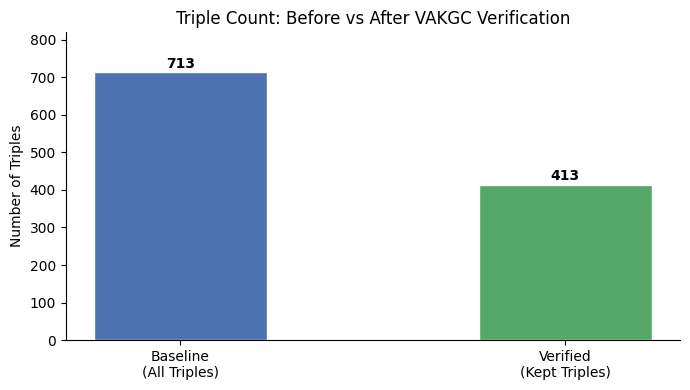

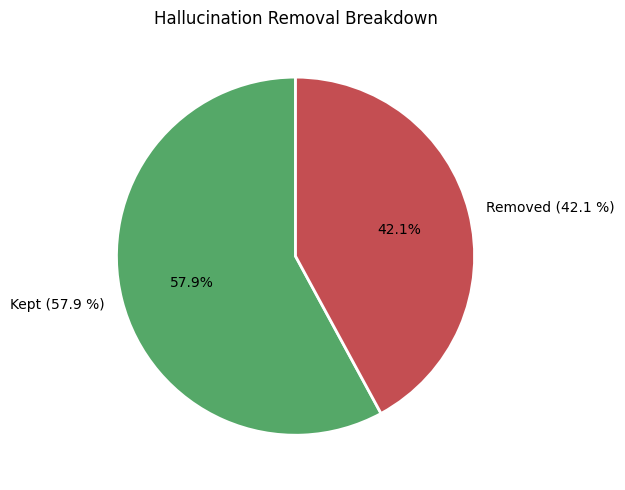

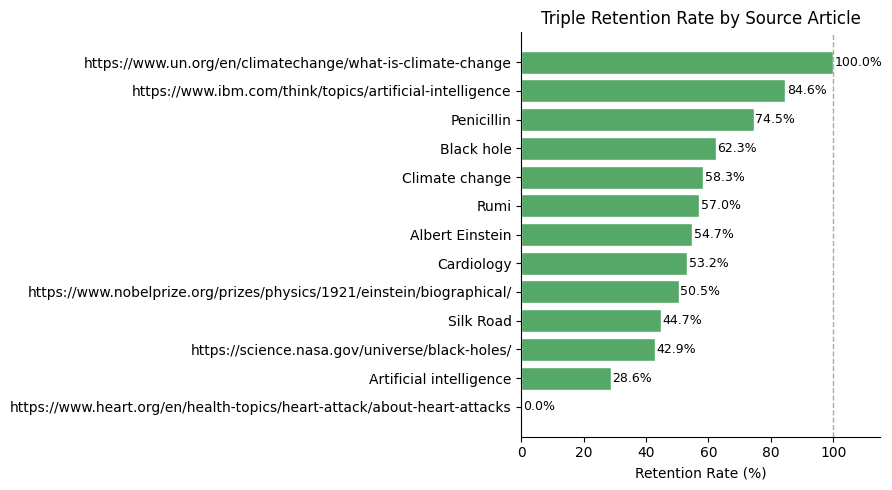

In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt

# ----------------------------
# LOAD FILES
# ----------------------------
baseline = pd.read_csv("baseline_dataset.csv")
verified = pd.read_csv("/content/verified_dataset.csv")

# ----------------------------
# COUNT VERIFIED TRIPLES
# ----------------------------
def count_verified(triple_str):
    try:
        triples = json.loads(triple_str)
        return len(triples)
    except:
        return 0

verified["verified_count"] = verified["verified_triples"].apply(count_verified)

# ----------------------------
# TOTAL METRICS
# ----------------------------
baseline_total     = int(baseline["triple_count"].sum())
verified_total     = int(verified["verified_count"].sum())
removed            = baseline_total - verified_total
retention          = (verified_total / baseline_total) * 100 if baseline_total else 0
hallucination_rate = (removed        / baseline_total) * 100 if baseline_total else 0
# Precision proxy: fraction of baseline triples that survived verification
precision_proxy    = round(verified_total / baseline_total, 4) if baseline_total else 0

# ----------------------------
# PRINT FINAL RESULTS
# ----------------------------
print("="*60)
print("VAKGC FINAL EVALUATION")
print("="*60)
print(f"Baseline triples       : {baseline_total}")
print(f"Verified (kept) triples: {verified_total}")
print(f"Removed (hallucinated) : {removed}")
print("-"*60)
print(f"Retention Rate         : {round(retention, 2)} %")
print(f"Hallucination Rate     : {round(hallucination_rate, 2)} %")
print(f"Precision Proxy        : {precision_proxy}")
print("="*60)

# ----------------------------
# COMPARISON TABLE  (fixed: baseline column now correct)
# ----------------------------
comparison = pd.DataFrame({
    "Metric"             : ["Total Triples", "Factual Triples", "Hallucinated Triples"],
    "Before (Baseline)"  : [baseline_total,  baseline_total,    0],
    "After  (Verified)"  : [baseline_total,  verified_total,    removed],
})
print("\nComparison Table:")
print(comparison.to_string(index=False))

# ----------------------------
# CHART 1: Baseline vs Verified bar chart
# ----------------------------
plt.figure(figsize=(7, 4))
bars = plt.bar(
    ["Baseline\n(All Triples)", "Verified\n(Kept Triples)"],
    [baseline_total, verified_total],
    color=["#4C72B0", "#55A868"],
    width=0.45, edgecolor="white"
)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 5,
             str(int(h)), ha="center", va="bottom", fontweight="bold")
plt.title("Triple Count: Before vs After VAKGC Verification")
plt.ylabel("Number of Triples")
plt.ylim(0, baseline_total * 1.15)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# ----------------------------
# CHART 2: Pie chart — kept vs removed
# ----------------------------
plt.figure(figsize=(6, 5))
plt.pie(
    [verified_total, removed],
    labels=[f"Kept ({round(retention,1)} %)", f"Removed ({round(hallucination_rate,1)} %)"],
    colors=["#55A868", "#C44E52"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
plt.title("Hallucination Removal Breakdown")
plt.tight_layout()
plt.show()

# ----------------------------
# CHART 3: Per-source retention rate
# ----------------------------
b_src = baseline.groupby("source")["triple_count"].sum().reset_index()
v_src = verified.groupby("source")["verified_count"].sum().reset_index()
src_df = b_src.merge(v_src, on="source", how="left").fillna(0)
src_df["retention_pct"] = (src_df["verified_count"] / src_df["triple_count"].replace(0,1) * 100).round(1)
src_df = src_df.sort_values("retention_pct")

plt.figure(figsize=(9, 5))
bars = plt.barh(src_df["source"], src_df["retention_pct"],
                color="#55A868", edgecolor="white")
for bar, val in zip(bars, src_df["retention_pct"]):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=9)
plt.axvline(100, color="#aaa", linewidth=1, linestyle="--")
plt.xlabel("Retention Rate (%)")
plt.title("Triple Retention Rate by Source Article")
plt.xlim(0, 115)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# PHASE 8: Knowledge Graph Construction & Visualization

**Goal:** Build and visualize two Knowledge Graphs side-by-side:
1. Baseline KG  — all raw triples (before verification)
2. Verified KG  — only NLI-verified triples (after filtering)

The comparison shows clearly how verification removes hallucinated
or unsupported edges and produces a cleaner, more trustworthy graph.

**Input files (from earlier phases):**
baseline_flat.csv   — Phase 3  | cols: sentence_id, sentence, source, subject, relation, object
verified_flat.csv   — Phase 4  | cols: sentence_id, sentence, source, subject, relation, object, confidence

**Output:**

kg_comparison.png   — side-by-side graph visualization

kg_verified_only.png— full-size verified KG for the report

In [21]:
!pip install -q networkx matplotlib pandas

In [22]:
import os
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [23]:
BASELINE_FLAT = "baseline_flat.csv"   # Phase 3 output
VERIFIED_FLAT = "verified_flat.csv"   # Phase 4 output

# Maximum number of triples to draw per graph.
# Large graphs get unreadable — keep this at 60–80 for clear visuals.
# If your dataset is smaller, set to None to draw everything.
MAX_TRIPLES_DISPLAY = 60

# Node label wrapping: max characters per line in a node label
MAX_LABEL_LEN = 22

# Visual style settings
NODE_COLOR_SUBJECT = "#4C72B0"    # blue  — subject nodes
NODE_COLOR_OBJECT  = "#55A868"    # green — object nodes
NODE_COLOR_BOTH    = "#DD8452"    # orange — nodes that are both subject & object
EDGE_COLOR_BASE    = "#C44E52"    # red   — baseline-only edges (hallucinated)
EDGE_COLOR_VERIFIED= "#4C72B0"   # blue  — verified edges
FONT_SIZE_NODE     = 7
FONT_SIZE_EDGE     = 5.5

In [24]:
def load_flat_csv(filepath: str) -> pd.DataFrame:
    """Load a flat triples CSV and drop rows that have no subject/relation/object."""
    if not os.path.exists(filepath):
        raise FileNotFoundError(
            f"File not found: '{filepath}'\n"
            f"Make sure Phase 3 and Phase 4 have run successfully."
        )
    df = pd.read_csv(filepath)

    # Drop rows where any core triple field is empty
    df = df.dropna(subset=["subject", "relation", "object"])
    df = df[
        (df["subject"].str.strip() != "") &
        (df["relation"].str.strip() != "") &
        (df["object"].str.strip() != "")
    ].reset_index(drop=True)

    print(f"  Loaded '{filepath}': {len(df)} valid triples")
    return df


def wrap_label(text: str, max_len: int = MAX_LABEL_LEN) -> str:
    """Wrap a long node label to multiple lines."""
    words = str(text).split()
    lines, current = [], ""
    for word in words:
        if len(current) + len(word) + 1 <= max_len:
            current = (current + " " + word).strip()
        else:
            if current:
                lines.append(current)
            current = word
    if current:
        lines.append(current)
    return "\n".join(lines)

In [25]:
def build_graph(df: pd.DataFrame) -> nx.DiGraph:
    """Build a directed graph from a flat triples DataFrame."""
    G = nx.DiGraph()

    for _, row in df.iterrows():
        subj = str(row["subject"]).strip()
        rel  = str(row["relation"]).strip()
        obj  = str(row["object"]).strip()

        G.add_node(subj)
        G.add_node(obj)

        if G.has_edge(subj, obj):
            existing = G[subj][obj]["label"]
            if rel not in existing:
                G[subj][obj]["label"] = existing + "\n" + rel
        else:
            G.add_edge(subj, obj, label=rel)

    return G


def node_colors(G: nx.DiGraph) -> list:
    """Assign color to each node based on its role."""
    subjects = set(u for u, v in G.edges())
    objects  = set(v for u, v in G.edges())
    colors   = []
    for node in G.nodes():
        if node in subjects and node in objects:
            colors.append(NODE_COLOR_BOTH)
        elif node in subjects:
            colors.append(NODE_COLOR_SUBJECT)
        else:
            colors.append(NODE_COLOR_OBJECT)
    return colors

In [26]:
def draw_graph(G: nx.DiGraph,
               ax,
               title: str,
               edge_color: str,
               max_triples: int = None):
    """Draw a knowledge graph on a given Matplotlib axis."""

    # Optionally trim to max_triples
    if max_triples and G.number_of_edges() > max_triples:
        edges_to_keep = list(G.edges(data=True))[:max_triples]
        nodes_to_keep = set()
        for u, v, _ in edges_to_keep:
            nodes_to_keep.add(u)
            nodes_to_keep.add(v)
        G = G.subgraph(nodes_to_keep).copy()

        all_edges = list(G.edges())
        keep_pairs = {(u, v) for u, v, _ in edges_to_keep}
        for u, v in all_edges:
            if (u, v) not in keep_pairs:
                G.remove_edge(u, v)
        title += f"\n(showing {G.number_of_edges()} of original edges)"

    # Layout
    pos = nx.spring_layout(G, seed=42, k=2.5)

    # Wrap node labels
    labels = {node: wrap_label(node) for node in G.nodes()}

    # Draw nodes
    colors = node_colors(G)
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=colors,
        node_size=900,
        alpha=0.92
    )

    # Draw node labels
    nx.draw_networkx_labels(
        G, pos, labels=labels, ax=ax,
        font_size=FONT_SIZE_NODE,
        font_color="white",
        font_weight="bold"
    )

    # Draw edges
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edge_color=edge_color,
        arrows=True,
        arrowsize=18,
        arrowstyle="-|>",
        width=1.4,
        connectionstyle="arc3,rad=0.08",
        alpha=0.80,
        min_source_margin=20,
        min_target_margin=20,
    )

    # Draw edge labels
    edge_labels = nx.get_edge_attributes(G, "label")
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels=edge_labels, ax=ax,
        font_size=FONT_SIZE_EDGE,
        font_color="#222222",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.6, ec="none"),
        label_pos=0.5,
    )

    # Title and stats
    ax.set_title(
        f"{title}\n"
        f"Nodes: {G.number_of_nodes()}   Edges: {G.number_of_edges()}",
        fontsize=11, fontweight="bold", pad=12
    )
    ax.axis("off")

In [27]:
# Ensure baseline_flat.csv exists (recreate if missing)
def ensure_baseline_flat_csv(baseline_csv_path="baseline_dataset.csv", output_flat_path="baseline_flat.csv"):
    if os.path.exists(output_flat_path):
        print(f"'{output_flat_path}' already exists. Skipping recreation.")
        return

    print(f"'{output_flat_path}' not found. Attempting to recreate from '{baseline_csv_path}'...")
    if not os.path.exists(baseline_csv_path):
        raise FileNotFoundError(f"Cannot recreate '{output_flat_path}'. '{baseline_csv_path}' is also missing.")

    baseline_df_source = pd.read_csv(baseline_csv_path)

    rows = []
    for _, record in baseline_df_source.iterrows():
        raw_triples_string = record["triples"]
        triples_list = json.loads(raw_triples_string)

        if len(triples_list) == 0:
            rows.append({
                "sentence_id": record["sentence_id"],
                "sentence": record["sentence"],
                "source": record["source"],
                "subject": "",
                "relation": "",
                "object": "",
            })
        else:
            for triple in triples_list:
                subject  = triple[0] if len(triple) > 0 else ""
                relation = triple[1] if len(triple) > 1 else ""
                obj      = triple[2] if len(triple) > 2 else ""
                rows.append({
                    "sentence_id": record["sentence_id"],
                    "sentence": record["sentence"],
                    "source": record["source"],
                    "subject": subject,
                    "relation": relation,
                    "object": obj,
                })

    with open(output_flat_path, "w", newline="", encoding="utf-8") as f:
        fieldnames = ["sentence_id", "sentence", "source", "subject", "relation", "object"]
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    print(f"Successfully recreated '{output_flat_path}'.")

# Ensure baseline_flat.csv exists
ensure_baseline_flat_csv(output_flat_path=BASELINE_FLAT)

# Verify verified_flat.csv exists before loading
if not os.path.exists(VERIFIED_FLAT):
    raise FileNotFoundError(
        f"'{VERIFIED_FLAT}' not found. "
        f"Make sure Phase 4 (Hallucination Detection) has completed successfully."
    )

print("Loading flat triple files …")
baseline_df = load_flat_csv(BASELINE_FLAT)
verified_df = load_flat_csv(VERIFIED_FLAT)

print(f"\n  Baseline triples : {len(baseline_df)}")
print(f"  Verified triples : {len(verified_df)}")
print(f"  Triples removed  : {len(baseline_df) - len(verified_df)}")

'baseline_flat.csv' already exists. Skipping recreation.
Loading flat triple files …
  Loaded 'baseline_flat.csv': 712 valid triples
  Loaded 'verified_flat.csv': 413 valid triples

  Baseline triples : 712
  Verified triples : 413
  Triples removed  : 299


In [28]:
print("\nBuilding graphs …")
G_baseline = build_graph(baseline_df)
G_verified = build_graph(verified_df)

print(f"  Baseline KG — nodes: {G_baseline.number_of_nodes()}, "
      f"edges: {G_baseline.number_of_edges()}")
print(f"  Verified  KG — nodes: {G_verified.number_of_nodes()}, "
      f"edges: {G_verified.number_of_edges()}")


Building graphs …
  Baseline KG — nodes: 756, edges: 681
  Verified  KG — nodes: 472, edges: 399



Drawing comparison chart …


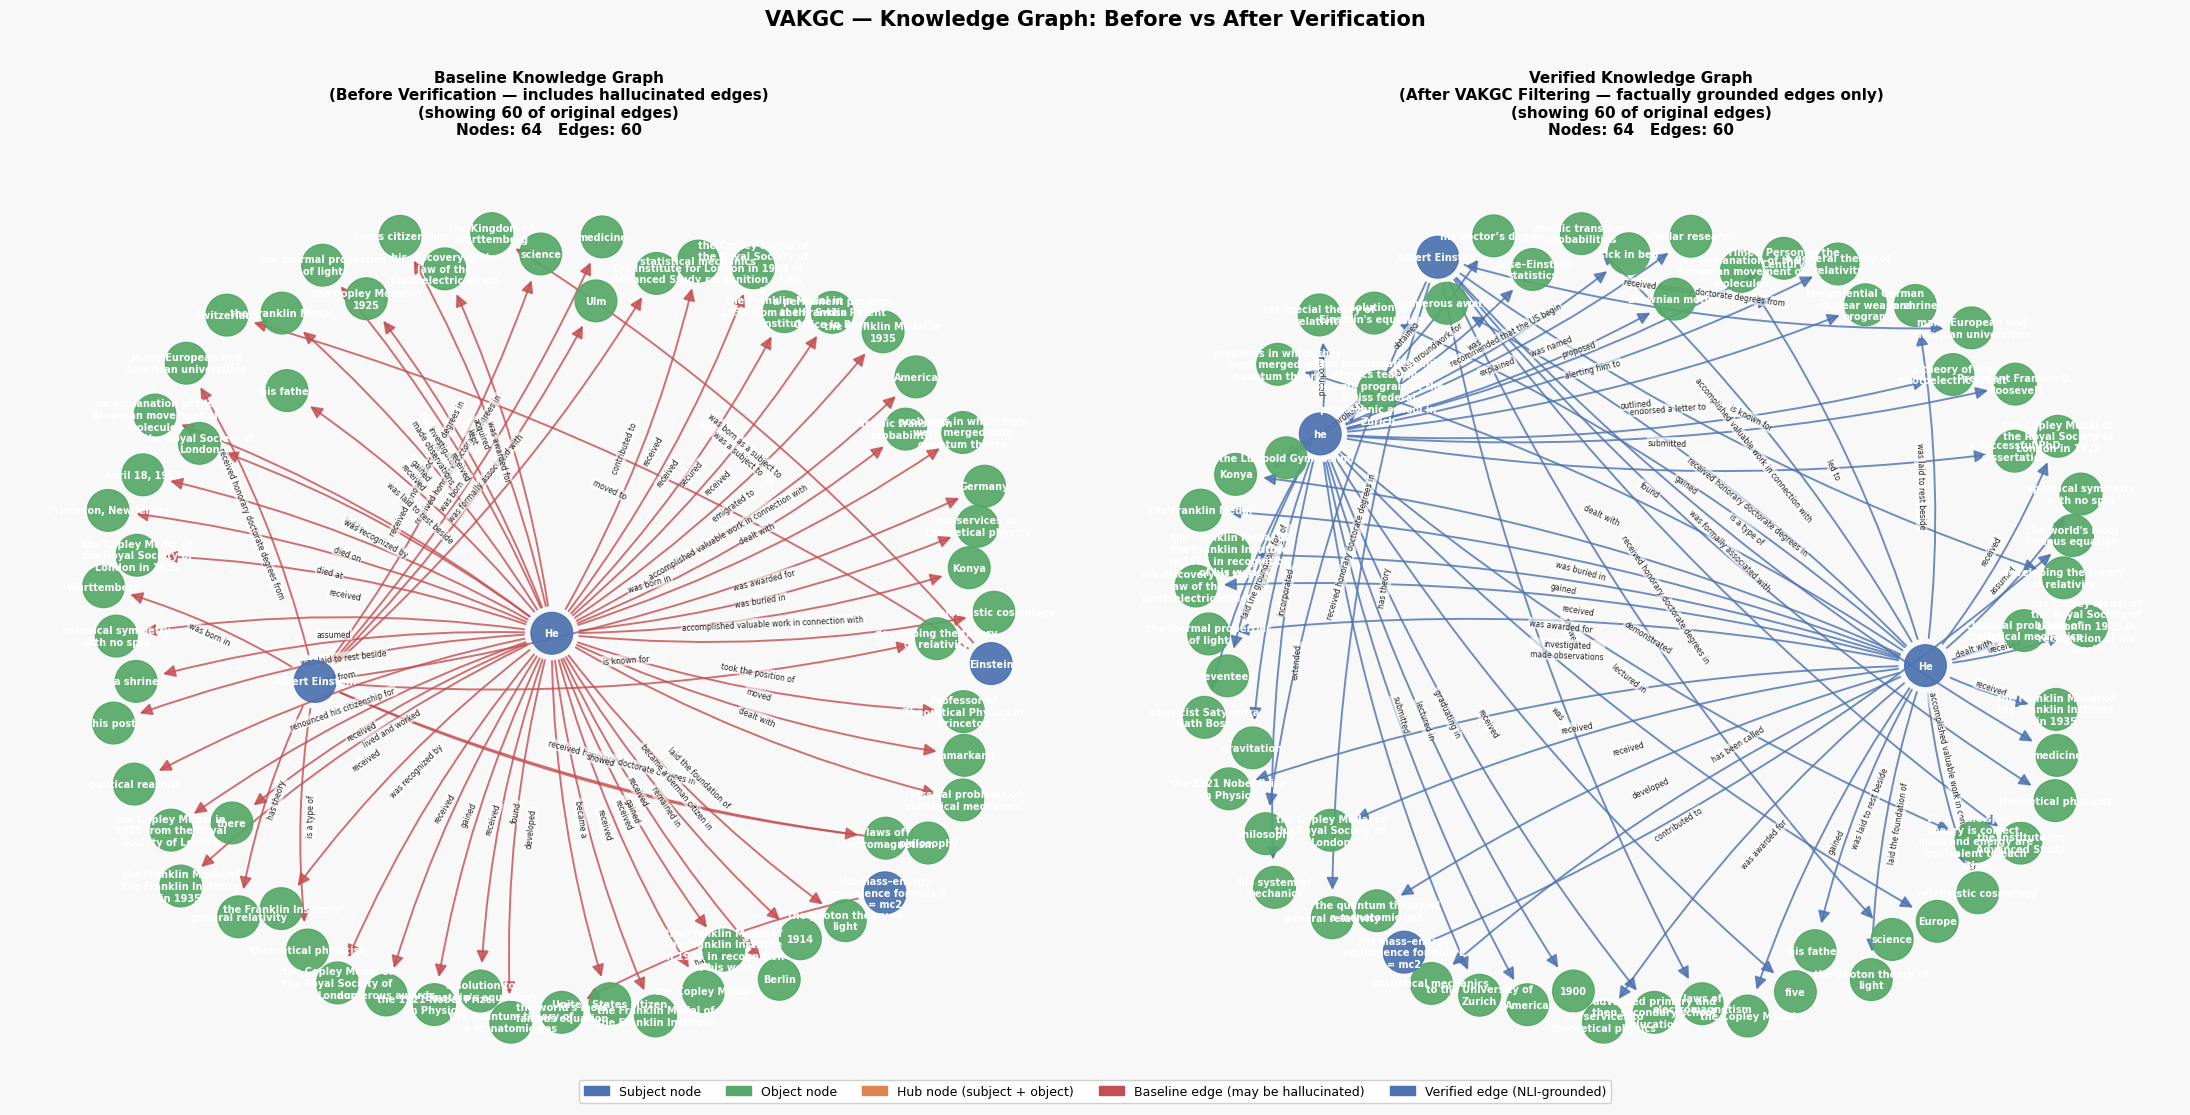

  Saved → kg_comparison.png


In [29]:
print("\nDrawing comparison chart …")

fig, (ax_base, ax_ver) = plt.subplots(
    1, 2,
    figsize=(22, 11),
    facecolor="#F8F8F8"
)
fig.subplots_adjust(wspace=0.08)

draw_graph(
    G_baseline, ax_base,
    title="Baseline Knowledge Graph\n(Before Verification — includes hallucinated edges)",
    edge_color=EDGE_COLOR_BASE,
    max_triples=MAX_TRIPLES_DISPLAY
)

draw_graph(
    G_verified, ax_ver,
    title="Verified Knowledge Graph\n(After VAKGC Filtering — factually grounded edges only)",
    edge_color=EDGE_COLOR_VERIFIED,
    max_triples=MAX_TRIPLES_DISPLAY
)

# Shared legend
legend_handles = [
    mpatches.Patch(color=NODE_COLOR_SUBJECT, label="Subject node"),
    mpatches.Patch(color=NODE_COLOR_OBJECT,  label="Object node"),
    mpatches.Patch(color=NODE_COLOR_BOTH,    label="Hub node (subject + object)"),
    mpatches.Patch(color=EDGE_COLOR_BASE,    label="Baseline edge (may be hallucinated)"),
    mpatches.Patch(color=EDGE_COLOR_VERIFIED,label="Verified edge (NLI-grounded)"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=5,
    fontsize=9,
    frameon=True,
    framealpha=0.9,
    edgecolor="#cccccc",
    bbox_to_anchor=(0.5, 0.01)
)

fig.suptitle(
    "VAKGC — Knowledge Graph: Before vs After Verification",
    fontsize=15, fontweight="bold", y=1.01
)

plt.tight_layout()
plt.savefig("kg_comparison.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("  Saved → kg_comparison.png")


Drawing full-size verified KG …


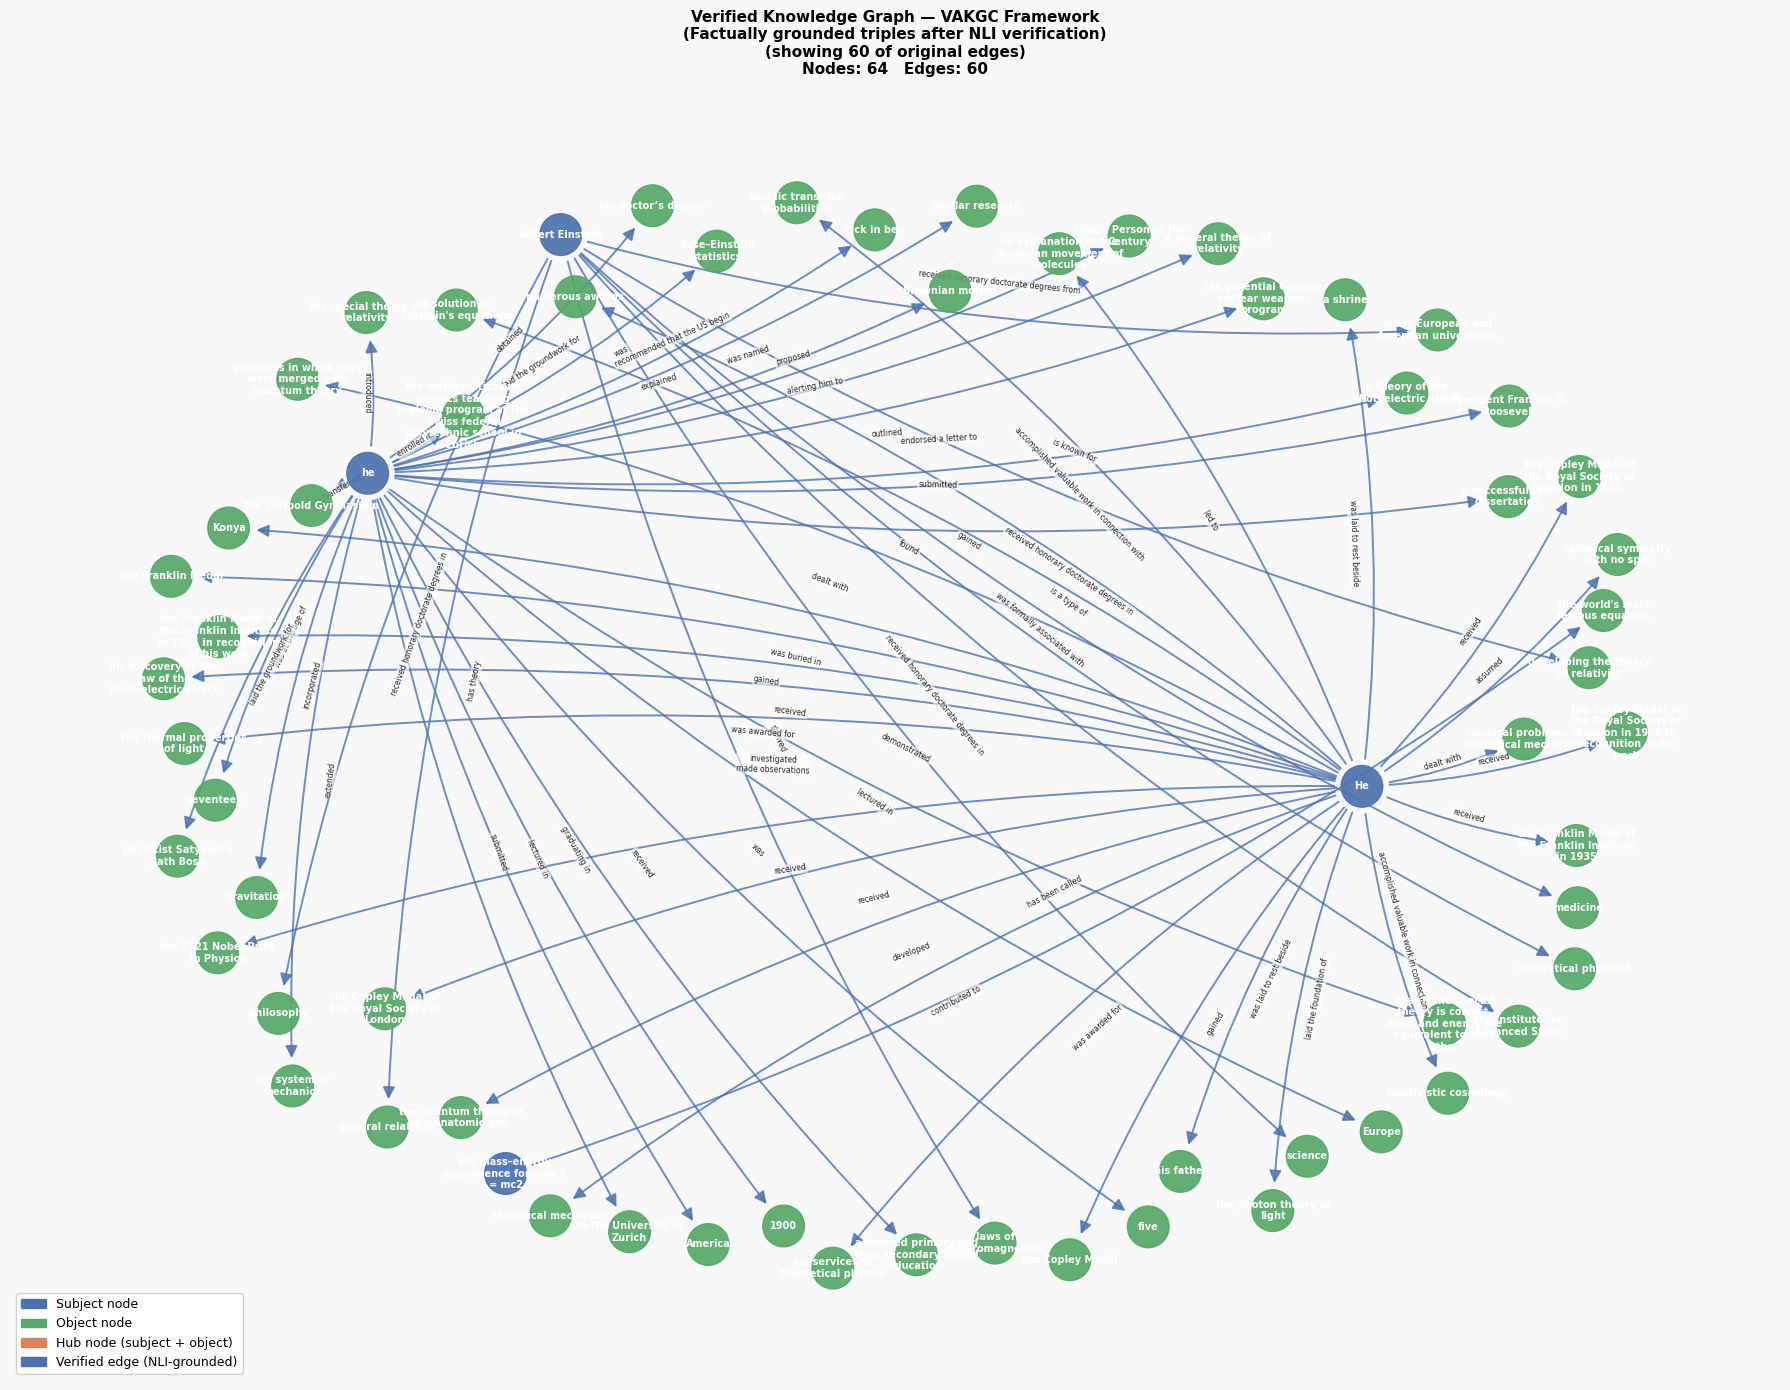

  Saved → kg_verified_only.png


In [30]:
print("\nDrawing full-size verified KG …")

fig2, ax2 = plt.subplots(figsize=(18, 14), facecolor="#F8F8F8")

draw_graph(
    G_verified, ax2,
    title="Verified Knowledge Graph — VAKGC Framework\n"
          "(Factually grounded triples after NLI verification)",
    edge_color=EDGE_COLOR_VERIFIED,
    max_triples=MAX_TRIPLES_DISPLAY
)

# Legend for single-graph view
legend_handles2 = [
    mpatches.Patch(color=NODE_COLOR_SUBJECT, label="Subject node"),
    mpatches.Patch(color=NODE_COLOR_OBJECT,  label="Object node"),
    mpatches.Patch(color=NODE_COLOR_BOTH,    label="Hub node (subject + object)"),
    mpatches.Patch(color=EDGE_COLOR_VERIFIED,label="Verified edge (NLI-grounded)"),
]
ax2.legend(
    handles=legend_handles2,
    loc="lower left",
    fontsize=9,
    frameon=True,
    framealpha=0.9,
    edgecolor="#cccccc"
)

plt.tight_layout()
plt.savefig("kg_verified_only.png", dpi=150, bbox_inches="tight",
            facecolor=fig2.get_facecolor())
plt.show()
print("  Saved → kg_verified_only.png")

In [31]:
print("\n" + "=" * 55)
print("  KNOWLEDGE GRAPH — STRUCTURAL COMPARISON")
print("=" * 55)

# Basic counts
b_nodes = G_baseline.number_of_nodes()
b_edges = G_baseline.number_of_edges()
v_nodes = G_verified.number_of_nodes()
v_edges = G_verified.number_of_edges()

print(f"  {'Metric':<30} {'Baseline':>10} {'Verified':>10}")
print("  " + "-" * 50)
print(f"  {'Nodes':<30} {b_nodes:>10} {v_nodes:>10}")
print(f"  {'Edges (triples)':<30} {b_edges:>10} {v_edges:>10}")
print(f"  {'Edges removed':<30} {'':>10} {b_edges - v_edges:>10}")
print(f"  {'Edge retention rate':<30} {'':>10} {v_edges/max(b_edges,1)*100:>9.1f}%")

# Density: edges / (nodes*(nodes-1))  — how connected the graph is
b_density = nx.density(G_baseline) if b_nodes > 1 else 0
v_density = nx.density(G_verified)  if v_nodes > 1 else 0
print(f"  {'Graph density':<30} {b_density:>10.4f} {v_density:>10.4f}")

# Average degree
b_avg_deg = sum(d for _, d in G_baseline.degree()) / max(b_nodes, 1)
v_avg_deg = sum(d for _, d in G_verified.degree())  / max(v_nodes, 1)
print(f"  {'Avg degree per node':<30} {b_avg_deg:>10.2f} {v_avg_deg:>10.2f}")

# Weakly connected components (groups of related entities)
b_wcc = nx.number_weakly_connected_components(G_baseline)
v_wcc = nx.number_weakly_connected_components(G_verified)
print(f"  {'Connected components':<30} {b_wcc:>10} {v_wcc:>10}")

print("=" * 55)

# Top 5 most connected nodes (hubs) in verified graph
print("\n  Top 5 hub nodes in Verified KG (by total degree):")
top_nodes = sorted(G_verified.degree(), key=lambda x: x[1], reverse=True)[:5]
for node, deg in top_nodes:
    print(f"    {node[:40]:<40}  degree={deg}")

print("\n  Output files:")
print("    kg_comparison.png    — side-by-side baseline vs verified")
print("    kg_verified_only.png — full-size verified KG for report")


  KNOWLEDGE GRAPH — STRUCTURAL COMPARISON
  Metric                           Baseline   Verified
  --------------------------------------------------
  Nodes                                 756        472
  Edges (triples)                       681        399
  Edges removed                                    282
  Edge retention rate                            58.6%
  Graph density                      0.0012     0.0018
  Avg degree per node                  1.80       1.69
  Connected components                  115         87

  Top 5 hub nodes in Verified KG (by total degree):
    he                                        degree=31
    He                                        degree=26
    Rumi                                      degree=19
    Einstein                                  degree=14
    Albert Einstein                           degree=9

  Output files:
    kg_comparison.png    — side-by-side baseline vs verified
    kg_verified_only.png — full-size verified KG for r